# Integrated energy grids - Assignment 1

## Imports

In [30]:
# Imports
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
from datetime import timedelta
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import sys
import importlib
from IPython.display import display

pd.options.display.width = 120

print('pandas', pd.__version__, 'numpy', np.__version__)

pandas 3.0.2 numpy 2.4.3


## Data collection

### Folder Setup

In [31]:
# List files in current directory
print("Current directory:", os.getcwd())
print("\nFiles in workspace:")
for file in os.listdir('.'):
    print(f"  {file}")

Current directory: d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment

Files in workspace:
  .git
  python_codes
  IEG_Course_Project_Part1.pdf
  Data
  Plots
  README.md
  back-up projects
  .vscode
  IEG_Assignment_Multi_country.ipynb
  IEG_Assignment_Single_country.ipynb


### CSV loading

- **Installed Capacity**
- **Hourly operating program**
- **Daily gas price**

In [32]:
# --- 1) Load CSV data (workspace files) ---
base = Path('./Data')
cap_file = base / 'export_InstalledCapacityGenerationTotal_2026-03-03_17_12.csv'
hourly_file = base / 'export_OperatingHourlyProgramGeneration+Storage+BalearicHVDCLinkP48_2026-03-03_17_22.csv'
gas_file = base / 'Gas prices Spain 2025.csv'

# Read installed capacities
cap_df = pd.read_csv(cap_file, sep=';')
cap_df = cap_df.rename(columns={'name':'tech','value':'capacity','start_date':'start','end_date':'end'})
print('installed capacities rows:', len(cap_df))
display(cap_df.head())

# Read hourly operating program (we treat 'value' as system demand/required generation)
hourly_df = pd.read_csv(hourly_file, sep=';')
hourly_df['datetime'] = pd.to_datetime(hourly_df['datetime'], utc=True)
hourly_df = hourly_df.set_index('datetime').sort_index()
print('hourly rows:', len(hourly_df))
display(hourly_df.head(3))

# Read gas price (daily)
gas_df = pd.read_csv(gas_file, sep=';', header=0)
# Clean up columns and decimals
gas_df.columns = [c.strip('"') for c in gas_df.columns]
gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)
gas_df['MIBGAS-ES Index'] = gas_df['MIBGAS-ES Index'].astype(str).str.replace(',', '.').astype(float)
gas_df = gas_df.set_index('Delivery Day')['MIBGAS-ES Index']
display(gas_df.head(3))

installed capacities rows: 27


,id,tech,geoid,geoname,capacity,start,end
0,1478,Installed capacity generation coal,NaN,NaN,241.200,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
1,1478,Installed capacity generation coal,NaN,NaN,570.050,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
2,1478,Installed capacity generation coal,NaN,NaN,1249.925,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
3,1483,Installed capacity generation combined cycle GT,NaN,NaN,26250.145,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
4,1489,Installed capacity generation cogeneration,NaN,NaN,5622.455,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00


hourly rows: 188498


,id,name,geoid,geoname,value
datetime,,,,,
2023-12-31 23:00:00+00:00,10024,Operating Hourly Program Generation + storage ...,NaN,NaN,21453.375
2023-12-31 23:00:00+00:00,92,Operating Hourly Program P48 Biogas,NaN,NaN,82.500
2023-12-31 23:00:00+00:00,91,Operating Hourly Program P48 Biomass,NaN,NaN,207.600


C:\Users\ccano\AppData\Local\Temp\ipykernel_4720\2052013660.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)


Delivery Day
2025-03-03    46.23
2025-03-04    44.69
2025-03-05    43.07
Name: MIBGAS-ES Index, dtype: float64

**Compilation of installed capacity**

In [33]:
# --- 2) Compile capacities by technology ---
cap_by_tech = cap_df.groupby('tech', dropna=False)['capacity'].sum().to_frame()
# Map long names to short technology keys (edit mapping as needed)
tech_map = {
    'Installed capacity generation combined cycle GT': 'CCGT',
    'Installed capacity generation coal': 'Coal',
    'Installed capacity generation nuclear': 'Nuclear',
    'Installed capacity generation wind': 'Wind',
    'Installed capacity generation hydro': 'Hydro',
    'Installed capacity generation solar': 'Solar',
    'Installed capacity generation solar PV': 'Solar',
    'Installed capacity generation solar thermal': 'Solar',
    'Installed capacity generation diesel engines': 'Diesel',
    'Installed capacity generation cogeneration': 'CHP',
    'Installed capacity generation other renewables': 'OtherRenew'
}
tech_caps = {}
for longname, cap in cap_by_tech['capacity'].items():
    key = tech_map.get(longname, longname)
    tech_caps[key] = tech_caps.get(key, 0.0) + float(cap)

# Filter to only Wind, Solar, and Hydro
tech_caps = {k: v for k, v in tech_caps.items() if k in ['Wind', 'Solar', 'Hydro']}
tech_caps = pd.Series(tech_caps).sort_values(ascending=False)
print('Aggregated technology capacities (MW):')
display(tech_caps)

Aggregated technology capacities (MW):


Solar    33947.119
Wind     31020.198
Hydro    17096.959
dtype: float64

**Hourly Demand Set-up**

In [34]:
# --- 3) Prepare hourly demand and hourly gas price series ---
demand = hourly_df['value'].rename('demand')
# Expand daily gas price to hourly (forward-fill)
# build hourly index covering demand range
hour_index = pd.date_range(start=demand.index[0].floor('D'), end=demand.index[-1].ceil('D') - timedelta(hours=1), freq='h')
print('demand range:', demand.index.min(), 'to', demand.index.max())
display(demand.head())

demand range: 2023-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00


datetime
2023-12-31 23:00:00+00:00    21453.375
2023-12-31 23:00:00+00:00       82.500
2023-12-31 23:00:00+00:00      207.600
2023-12-31 23:00:00+00:00        2.800
2023-12-31 23:00:00+00:00     3341.100
Name: demand, dtype: float64

**Generation by technology dataframe creation**

In [35]:
# Read full hourly file (raw multiple technologies)
df_raw = pd.read_csv(hourly_file, sep=';')
# parse datetimes
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], utc=True)

# helper to simplify long technology names
def simplify_name(n: str) -> str:
    # handle NaN or non-string
    if pd.isna(n):
        return 'Other'
    s = str(n).lower().strip()
    if not s:
        return 'Other'
    # Remove common prefixes/words that add noise
    for drop in ['operating hourly program', 'operating hourly program generation', 'operating hourly program p48', 'operating hourly program p48 ', 'p48', 'balearic', 'hvdc link', '+', '/', '\\n']:
        s = s.replace(drop, ' ')
    s = ' '.join(s.split())
    # mapping by keywords
    if 'hydro' in s:
        return 'Hydro'
    if 'wind' in s:
        return 'Wind'
    if 'solar' in s or 'pv' in s:
        return 'Solar'
    if 'coal' in s:
        return 'Coal'
    if 'nuclear' in s:
        return 'Nuclear'
    if 'combined cycle' in s or 'ccgt' in s or 'combined' in s:
        return 'CCGT'
    if 'diesel' in s or 'diesel engines' in s:
        return 'Diesel'
    if 'cogeneration' in s or 'chp' in s:
        return 'CHP'
    if 'storage' in s or 'battery' in s or 'pumping' in s or 'turbine pumping' in s or 'pump' in s:
        return 'Storage'
    if 'hvdc' in s or 'link' in s:
        return 'HVDC'
    if 'waste' in s:
        return 'Waste'
    if 'other' in s or 'renew' in s:
        return 'OtherRenew'
    # fallback: take first meaningful token
    toks = [t for t in s.split() if any(c.isalpha() for c in t)]
    if toks:
        tok = toks[0]
        return tok.capitalize()
    return 'Other'

# Apply simplification
if 'name' not in df_raw.columns:
    df_raw['name'] = 'Unknown'

df_raw['tech'] = df_raw['name'].apply(simplify_name)

# Keep only relevant columns
df_small = df_raw[['datetime', 'tech', 'value']].copy()
# convert value to numeric
df_small['value'] = pd.to_numeric(df_small['value'], errors='coerce').fillna(0.0)

# Pivot: index=datetime, columns=tech, aggregate by sum (some hours may have multiple rows per tech)
gen_by_tech = df_small.pivot_table(index='datetime', columns='tech', values='value', aggfunc='sum')

# drop storage column entirely if present
if 'Storage' in gen_by_tech.columns:
    gen_by_tech = gen_by_tech.drop(columns=['Storage'])

# ensure non‑negative
gen_by_tech = gen_by_tech.clip(lower=0)

# Ensure full hourly index covering the range of 2024 data present in CSV
full_index = pd.date_range(start=gen_by_tech.index.min().floor('D'), end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1), freq='h')
gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
# set name for index
gen_by_tech.index.name = 'datetime'

# add demand column equal to sum of technologies (excluding negative values)
gen_by_tech['demand'] = gen_by_tech.clip(lower=0).sum(axis=1)

print('Generated DataFrame `gen_by_tech` with shape:', gen_by_tech.shape)
display(gen_by_tech.head())

# Save to csv for later use
gen_by_tech.to_csv('./Data/generation_by_tech_2024.csv')


Generated DataFrame `gen_by_tech` with shape: (8808, 18)


tech,Biogas,Biomass,CCGT,CHP,Coal,Fossil,Generic,Hydro,Mining,Nuclear,Other,OtherRenew,Residual,Scheduled,Solar,Waste,Wind,demand
datetime,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 04:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Sample week**

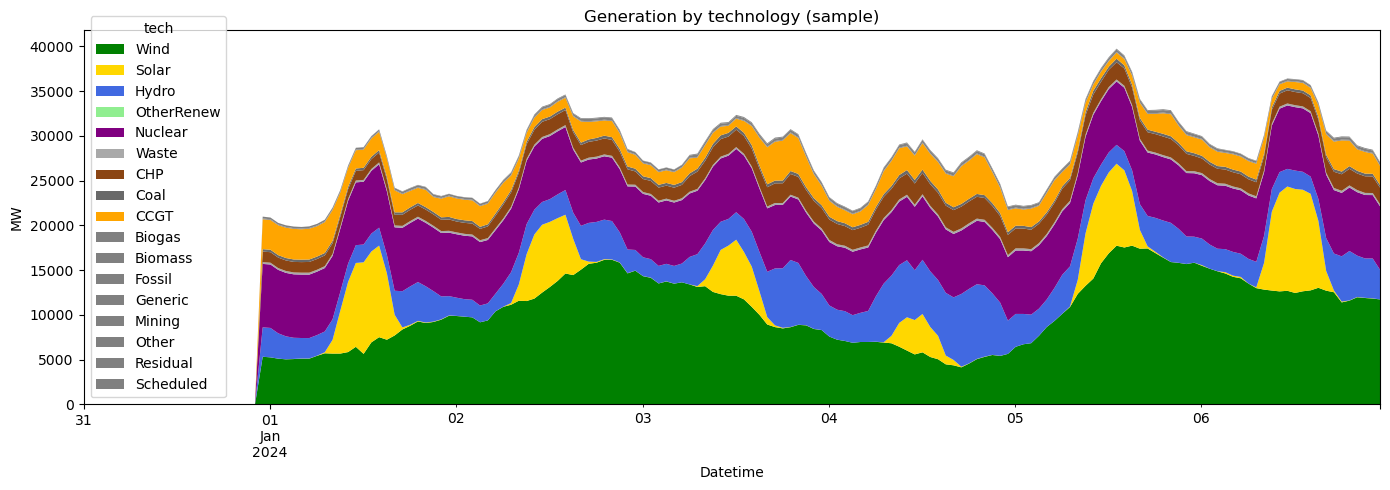

In [36]:
# --- Plot `gen_by_tech` (stacked area) ---
import matplotlib.pyplot as plt

if 'gen_by_tech' not in globals():
    raise RuntimeError('`gen_by_tech` not found. Run the earlier cell that constructs it first.')

# choose sample length (first week = 168 hours) for readability
sample_hours = 168
sample = gen_by_tech.iloc[:sample_hours] if len(gen_by_tech) >= sample_hours else gen_by_tech

# drop the demand column before plotting
plot_df = sample.drop(columns=['demand'], errors='ignore')

# define a consistent color mapping for technologies
color_map = {
    'Wind': 'green',
    'Solar': 'gold',
    'Hydro': 'royalblue',
    'Coal': 'dimgray',
    'Nuclear': 'purple',
    'Diesel': 'red',
    'CCGT': 'orange',
    'CHP': 'saddlebrown',
    'HVDC': 'black',
    'OtherRenew': 'lightgreen',
    'Waste': 'darkgray'
}

# Order technologies by cost (cheapest at bottom, most expensive at top)
# This order is based on typical marginal costs
tech_cost_order = ['Wind', 'Solar', 'Hydro', 'OtherRenew', 'Nuclear', 'Waste', 'HVDC', 'CHP', 'Coal', 'CCGT', 'Diesel']
ordered_cols = [col for col in tech_cost_order if col in plot_df.columns]
# Add any remaining columns not in the order list
ordered_cols += [col for col in plot_df.columns if col not in ordered_cols]
plot_df = plot_df[ordered_cols]

# pick colors in the order of plot columns; fallback to gray if not mapped
colors = [color_map.get(col, 'gray') for col in plot_df.columns]


ax = plot_df.plot.area(figsize=(14,5), linewidth=0, color=colors)

ax.set_title('Generation by technology (sample)')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
plt.tight_layout()
plt.show()

**Renewable energy limits and Demand for the optimization**

Wind capacity: 31020.20 MW
Solar capacity: 33947.12 MW
Hydro capacity: 17096.96 MW

Winter: found 12 full weeks
Winter week range: 2024-12-15 00:00:00+00:00 to 2024-12-21 23:00:00+00:00

Summer: found 13 full weeks
Summer week range: 2024-07-13 00:00:00+00:00 to 2024-07-19 23:00:00+00:00



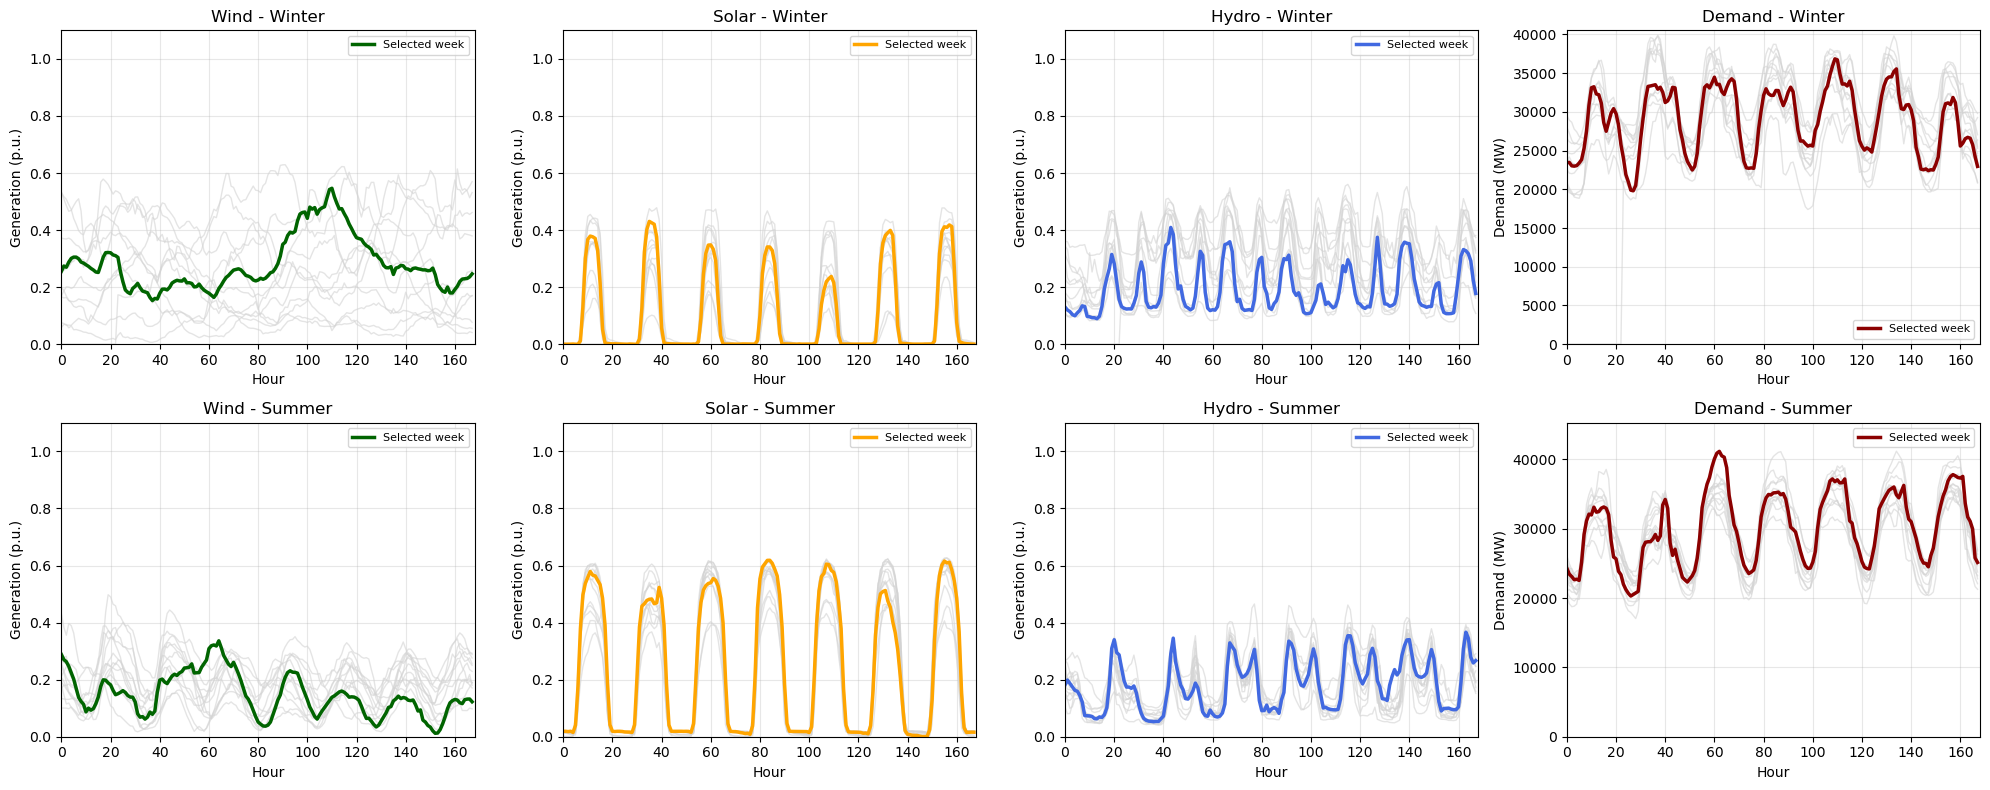

In [37]:
# --- Calculate p.u. generation for Wind, Solar, and Hydro + Demand ---
season_months = {
    'Winter': [12, 1, 2],
    'Summer': [6, 7, 8]
}

# Get capacities for p.u. calculation
wind_cap = tech_caps.get('Wind', 1.0)
solar_cap = tech_caps.get('Solar', 1.0)
hydro_cap = tech_caps.get('Hydro', 1.0)

print(f"Wind capacity: {wind_cap:.2f} MW")
print(f"Solar capacity: {solar_cap:.2f} MW")
print(f"Hydro capacity: {hydro_cap:.2f} MW\n")

# Store all weekly data and random selection per season
all_weekly_data = {}
pu_gen = {}

for season, months in season_months.items():
    # Subset data for season
    gb = gen_by_tech.copy()
    season_data = gb[gb.index.month.isin(months)]
    
    # Extract 7-day windows
    weekly = []
    start = season_data.index[0].floor('D')
    end = season_data.index[-1].ceil('D')
    current = start
    while current + pd.Timedelta(days=7) <= end:
        week_slice = season_data.loc[current:current + pd.Timedelta(days=7) - pd.Timedelta(hours=1)]
        if len(week_slice) == 168:
            weekly.append(week_slice)
        current += pd.Timedelta(days=7)
    
    print(f"{season}: found {len(weekly)} full weeks")
    
    # Store all weeks' p.u. data and demand
    all_weekly_data[season] = {'Wind': [], 'Solar': [], 'Hydro': [], 'Demand': []}
    for week_data in weekly:
        all_weekly_data[season]['Wind'].append(week_data.get('Wind', pd.Series(0, index=week_data.index)).values / wind_cap)
        all_weekly_data[season]['Solar'].append(week_data.get('Solar', pd.Series(0, index=week_data.index)).values / solar_cap)
        all_weekly_data[season]['Hydro'].append(week_data.get('Hydro', pd.Series(0, index=week_data.index)).values / hydro_cap)
        all_weekly_data[season]['Demand'].append(week_data.get('demand', pd.Series(0, index=week_data.index)).values)
    
    # Select random week
    if weekly:
        random_idx = np.random.randint(0, len(weekly))
        random_week = weekly[random_idx]
        
        # Store random week data
        pu_gen[season] = pd.DataFrame(index=random_week.index)
        pu_gen[season]['Wind'] = random_week.get('Wind', pd.Series(0, index=random_week.index)) / wind_cap
        pu_gen[season]['Solar'] = random_week.get('Solar', pd.Series(0, index=random_week.index)) / solar_cap
        pu_gen[season]['Hydro'] = random_week.get('Hydro', pd.Series(0, index=random_week.index)) / hydro_cap
        pu_gen[season]['Demand'] = random_week.get('demand', pd.Series(0, index=random_week.index))
        
        print(f"{season} week range: {random_week.index[0]} to {random_week.index[-1]}\n")

# Plot p.u. generation and demand for random weeks with all weeks in background
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

colors = {'Wind': 'darkgreen', 'Solar': 'orange', 'Hydro': 'royalblue', 'Demand': 'darkred'}

# Calculate common x-axis limits
x_max = max(len(data) for data in pu_gen.values())

for row, (season, data) in enumerate(pu_gen.items()):
    for col, tech in enumerate(['Wind', 'Solar', 'Hydro', 'Demand']):
        ax = axes[row, col]
        
        # Plot all weeks in light grey
        for week_profile in all_weekly_data[season][tech]:
            ax.plot(range(len(week_profile)), week_profile, 
                    color='lightgrey', linewidth=1.0, alpha=0.6)
        
        # Overlay random week in bold color
        ax.plot(range(len(data)), data[tech].values, 
                color=colors[tech], linewidth=2.5, label='Selected week')
        
        ax.set_title(f"{tech} - {season}")
        if tech == 'Demand':
            ax.set_ylabel('Demand (MW)')
            ax.set_ylim([0, max(data[tech].values) * 1.1])
        else:
            ax.set_ylabel('Generation (p.u.)')
            ax.set_ylim([0, 1.1])
        ax.set_xlabel('Hour')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, x_max])
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

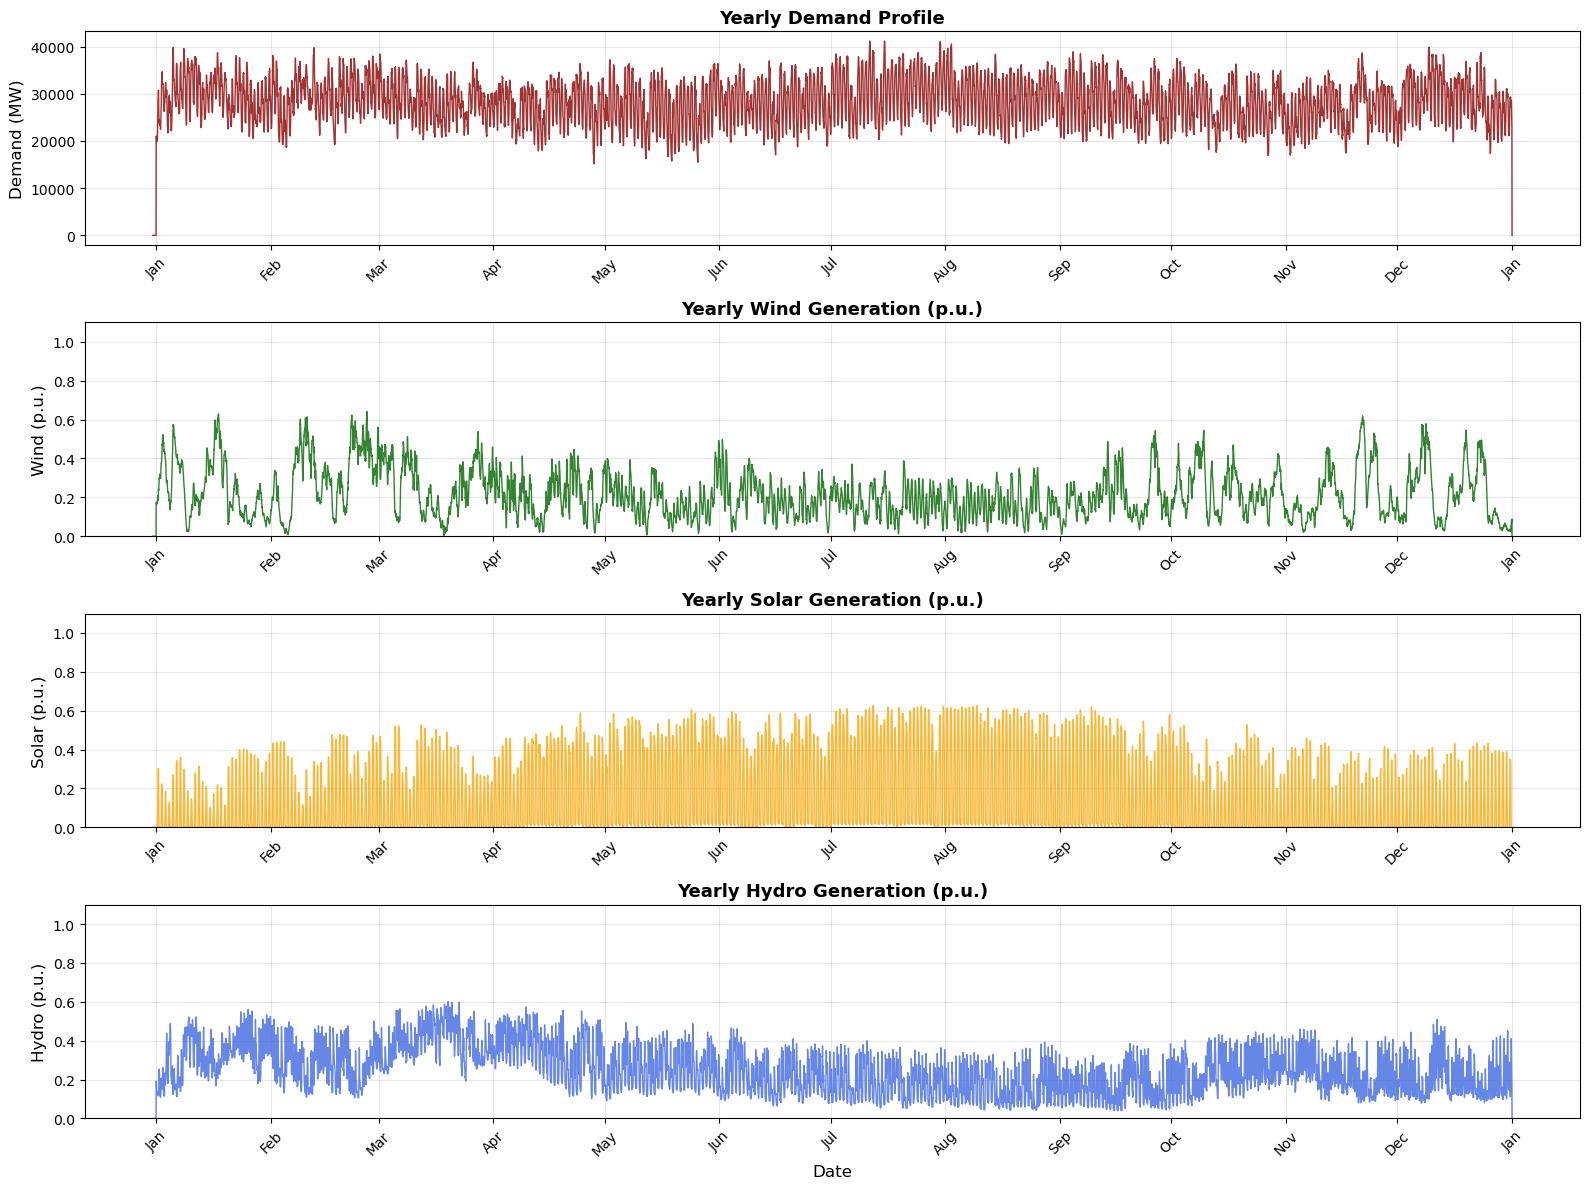

Demand (MW):
  Average: 28246.14
  Peak: 41177.93
  Min: 0.00

Wind Generation (p.u.):
  Average: 0.216
  Peak: 0.641
  Min: 0.000

Solar Generation (p.u.):
  Average: 0.161
  Peak: 0.627
  Min: 0.000

Hydro Generation (p.u.):
  Average: 0.240
  Peak: 0.601
  Min: 0.000


In [38]:
# Plot yearly Demand + Solar, Wind, and Hydro in p.u.
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Calculate p.u. values for each technology
wind_pu = gen_by_tech['Wind'] / wind_cap
solar_pu = gen_by_tech['Solar'] / solar_cap
hydro_pu = gen_by_tech['Hydro'] / hydro_cap
yearly_demand = gen_by_tech['demand']

# Plot Demand
axes[0].plot(yearly_demand.index, yearly_demand.values, color='darkred', linewidth=1, alpha=0.8)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_title('Yearly Demand Profile', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Wind
axes[1].plot(wind_pu.index, wind_pu.values, color='darkgreen', linewidth=1, alpha=0.8)
axes[1].set_ylabel('Wind (p.u.)', fontsize=12)
axes[1].set_title('Yearly Wind Generation (p.u.)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.1])

# Plot Solar
axes[2].plot(solar_pu.index, solar_pu.values, color='orange', linewidth=1, alpha=0.8)
axes[2].set_ylabel('Solar (p.u.)', fontsize=12)
axes[2].set_title('Yearly Solar Generation (p.u.)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.1])

# Plot Hydro
axes[3].plot(hydro_pu.index, hydro_pu.values, color='royalblue', linewidth=1, alpha=0.8)
axes[3].set_ylabel('Hydro (p.u.)', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_title('Yearly Hydro Generation (p.u.)', fontsize=13, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim([0, 1.1])

# Format x-axis to show months for all subplots
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Print statistics
print("Demand (MW):")
print(f"  Average: {yearly_demand.mean():.2f}")
print(f"  Peak: {yearly_demand.max():.2f}")
print(f"  Min: {yearly_demand.min():.2f}\n")

print("Wind Generation (p.u.):")
print(f"  Average: {wind_pu.mean():.3f}")
print(f"  Peak: {wind_pu.max():.3f}")
print(f"  Min: {wind_pu.min():.3f}\n")

print("Solar Generation (p.u.):")
print(f"  Average: {solar_pu.mean():.3f}")
print(f"  Peak: {solar_pu.max():.3f}")
print(f"  Min: {solar_pu.min():.3f}\n")

print("Hydro Generation (p.u.):")
print(f"  Average: {hydro_pu.mean():.3f}")
print(f"  Peak: {hydro_pu.max():.3f}")
print(f"  Min: {hydro_pu.min():.3f}")

## Capacity Expansion Optimization

This cell solves a **capacity expansion planning problem** to determine optimal technology capacities for Spain's electricity system over a full year (2024).

**What it does:**
- Optimizes technology capacities (MW) for Wind, Solar, Hydro, CCGT, Coal, and Nuclear
- Minimizes total annual system cost = Fixed costs (capacity-dependent) + Variable costs (generation-dependent)
- Satisfies hourly electricity demand across all 8,760 hours of the year
- Respects renewable generation profiles (capacity factors for wind, solar, hydro)
- Applies hydro capacity constraint (limited to baseline capacity from historical data)
- Uses PyPSA with solver chain: CBC → GLPK → Gurobi fallback

**Key inputs:** 
- Yearly demand profile (8,784 hours)
- Renewable capacity factor profiles (p.u. normalized 0-1)
- Technology cost parameters (fixed cost €/MW/year, variable cost €/MWh)
- Hydro baseline capacity constraint (~4,698 MW)

**Key outputs:** 
- Optimal installed capacities by technology (MW)
- Hourly generation dispatch by technology (MWh)
- Total annual system cost (€)
- Cost breakdown by technology: Fixed costs, Variable costs
- Annual electricity generation mix (% by technology)

### Mathematical Formulation

**Sets:**
- $T$ = Set of technologies (Wind, Solar, Hydro, CCGT, Coal, Nuclear)
- $H$ = Set of hourly time steps ($h = 1, 2, ..., 8760$)

**Parameters:**
- $D_h$ = Electricity demand at hour $h$ (MWh)
- $CF_{t,h}$ = Capacity factor (p.u., 0-1) for technology $t$ at hour $h$ (for renewables; = 1 for dispatchable)
- $FC_t$ = Fixed cost for technology $t$ (€/MW/year)
- $VC_t$ = Variable cost for technology $t$ (€/MWh)
- $C_{t}^{max}$ = Maximum capacity for technology $t$ (MW); for Hydro: $C_{Hydro}^{max} = 4,698$ MW

**Decision Variables:**
- $C_t$ = Installed capacity for technology $t$ (MW) — continuous, $C_t \geq 0$
- $G_{t,h}$ = Generation from technology $t$ at hour $h$ (MWh) — continuous, $G_{t,h} \geq 0$

**Objective Function:**

Minimize total annual system cost:
$$\min Z = \sum_{t \in T} FC_t \cdot C_t + \sum_{t \in T} \sum_{h \in H} VC_t \cdot G_{t,h}$$

where:
- First term: Total fixed (annualized capital + O&M) costs
- Second term: Total variable costs

**Constraints:**

1. **Power Balance (Demand satisfaction):** For each hour $h$:
$$\sum_{t \in T} G_{t,h} = D_h \quad \forall h \in H$$

2. **Renewable Generation Limits:** For renewable technologies (Wind, Solar, Hydro) at hour $h$:
$$G_{t,h} \leq CF_{t,h} \cdot C_t \quad \forall t \in T_{renewable}, \forall h \in H$$

3. **Dispatchable Generation Limits:** For non-renewable technologies (CCGT, Coal, Nuclear) at hour $h$:
$$G_{t,h} \leq C_t \quad \forall t \in T_{dispatchable}, \forall h \in H$$

4. **Capacity Limits:** (used only for hydro)
$$0 \leq C_t \leq C_t^{max} \quad \forall t \in T$$
    

Available technologies in cost file:


,Technology,Category,Overnight Cost,FOM (%/a),Fuel Cost (€/MWh)
0,Wind onshore,wind,1182,3.0,0.00
1,Wind offshore,wind,2506,3.0,0.00
2,Solar PV rooftop,solar,725,2.0,0.00
3,Solar PV utility,solar,425,3.0,0.00
4,Pumped hydro storage,hydro,2000,1.0,0.00
5,Hydro reservoir,hydro,2000,1.0,0.00
6,Run-of-river,hydro,3000,2.0,0.00
7,Combined heat and power (CHP) central,chp,600,3.0,87.50
8,Open cycle gas turbine (OCGT),fossil,400,4.0,30.00
9,Coal,coal,3000,3.0,61.52


Wind: Fixed cost = €35460.0/MW/year, Fuel cost = €0.00/MWh
Solar: Fixed cost = €14500.0/MW/year, Fuel cost = €0.00/MWh
Hydro: Fixed cost = €20000.0/MW/year, Fuel cost = €0.00/MWh
CCGT: Fixed cost = €16000.0/MW/year, Fuel cost = €30.00/MWh
Coal: Fixed cost = €90000.0/MW/year, Fuel cost = €61.52/MWh
Nuclear: Fixed cost = €150000.0/MW/year, Fuel cost = €8.50/MWh

Hydro capacity constraint: max = 17,097 MW (from baseline data)

CAPACITY EXPANSION OPTIMIZATION (YEARLY)
Demand data: 8808 hours (100.5% of year)
Wind: capacity factor = 0.216
Solar: capacity factor = 0.161
Hydro: capacity factor = 0.240

Yearly demand range: 0 - 41178 MW
Annual demand: 248,792,024 MWh

Running capacity expansion optimization with Gurobi...


d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment\python_codes\Abstract_model.py:243: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(
Index(['electricity'], dtype='str', name='name')


Optimizing with gurobi...


...

Optimal objective  4.723157419e+09


INFO:gurobipy:Optimal objective  4.723157419e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52854 primals, 114516 duals
Objective: 4.72e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


✓ Optimization complete

  Checking network contents:
    generators index: ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
    Available columns in generators:
      - bus
      - control
      - type
      - p_nom
      - p_nom_mod
      - p_nom_extendable
      - p_nom_min
      - p_nom_max
      - p_nom_set
      - p_min_pu
      - p_max_pu
      - p_set
      - p_init
      - e_sum_min
      - e_sum_max
      - q_set
      - sign
      - carrier
      - marginal_cost
      - marginal_cost_quadratic
      - active
      - build_year
      - lifetime
      - capital_cost
      - overnight_cost
      - discount_rate
      - fom_cost
      - efficiency
      - committable
      - start_up_cost
      - shut_down_cost
      - stand_by_cost
      - min_up_time
      - min_down_time
      - up_time_before
      - down_time_before
      - ramp_limit_up
      - ramp_limit_down
      - ramp_limit_start_up
      - ramp_limit_shut_down
      - weight
      - p_nom_opt

  Checking solutio

,Technology,Capacity (MW),Fixed Cost (€/MW/year),Variable Cost (€/MWh),Annual Fixed (€)
0,Wind,53970.0,"35,460",0,"1,913,761,334"
1,Solar,52592.0,"14,500",0,"762,577,561"
3,CCGT,25280.0,"16,000",30,"404,482,972"
2,Hydro,17097.0,"20,000",0,"341,939,180"
4,Coal,0.0,"90,000",62,0
5,Nuclear,0.0,"150,000",8,0



GENERATION BY REPRESENTATIVE WEEK


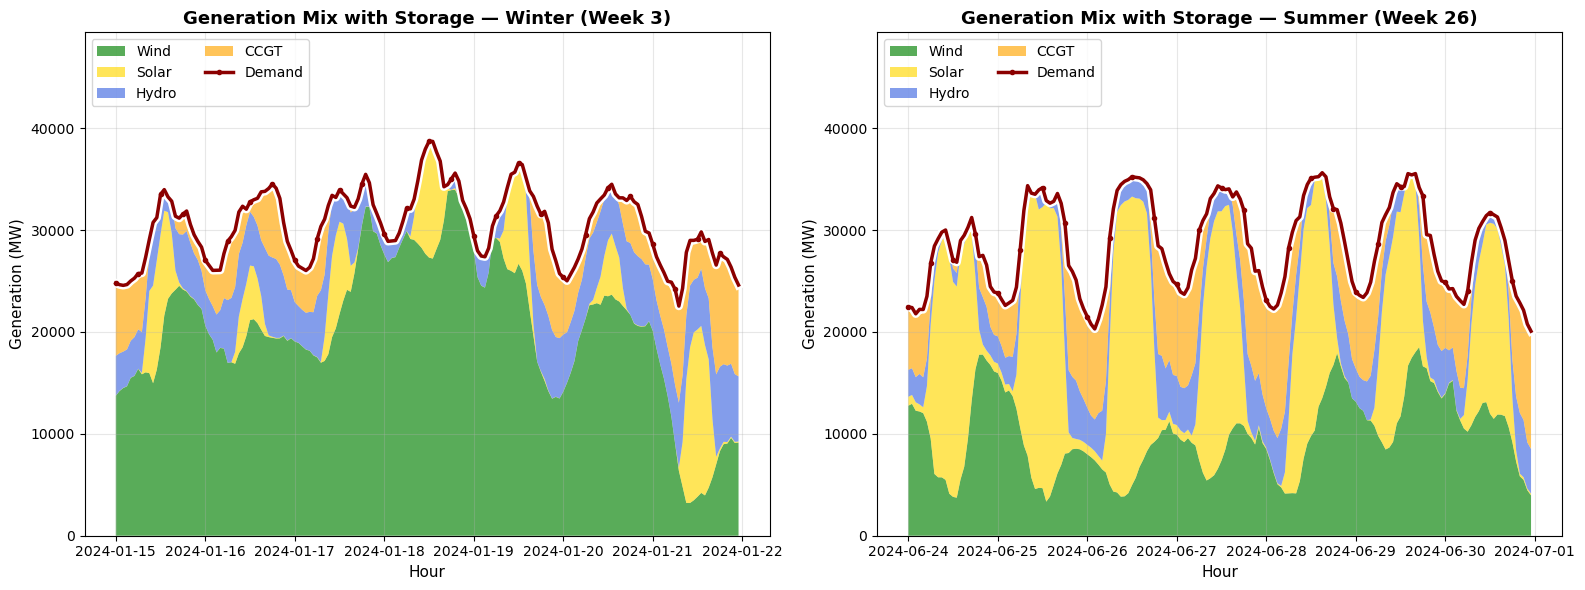


COST BREAKDOWN



,Technology,Fixed Cost (€),Variable Cost (€),Total (€)
3,CCGT,"404,482,972","1,300,396,372","1,704,879,344"
4,Coal,0,0,0
2,Hydro,"341,939,180",0,"341,939,180"
5,Nuclear,0,0,0
1,Solar,"762,577,561",0,"762,577,561"
0,Wind,"1,913,761,334",0,"1,913,761,334"


In [39]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import os
import shutil

module_dir = Path.cwd() / "python codes"
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

# === Force reload of Abstract_model ===
pycache_dir = module_dir / "__pycache__"
if pycache_dir.exists():
    shutil.rmtree(pycache_dir)

mods_to_remove = [mod for mod in sys.modules if 'Abstract_model' in mod]
for mod in mods_to_remove:
    del sys.modules[mod]

from python_codes.Abstract_model import CapacityExpansionInput, optimize_capacity_expansion

# === Load technology costs from CSV ===
cost_df = pd.read_csv('./Data/Techs_cost_FOM_&_Fuel_cost.csv')
print("Available technologies in cost file:")
display(cost_df[['Technology', 'Category', 'Overnight Cost', 'FOM (%/a)', 'Fuel Cost (€/MWh)']])

# Map technologies to our naming convention
tech_mapping = {
    'Wind': ['Wind onshore', 'Wind offshore'],
    'Solar': ['Solar PV rooftop', 'Solar PV utility'],
    'Hydro': ['Hydro reservoir', 'Run-of-river', 'Pumped hydro storage'],
    'CCGT': ['Open cycle gas turbine (OCGT)'],
    'CHP': ['Combined heat and power (CHP) central'],
    'Coal': ['Coal'],
    'Nuclear': ['Nuclear'],
}

# Aggregate costs by technology category
def aggregate_costs(tech_name, cost_df, tech_mapping, avg_gas_price=35.0):
    """Aggregate costs for a technology category."""
    matching_rows = cost_df[cost_df['Technology'].isin(tech_mapping.get(tech_name, []))]
    if len(matching_rows) == 0:
        return None
    
    # Use the first matching row (or could do weighting)
    row = matching_rows.iloc[0]
    
    # Overnight cost: €/kWel -> €/MW
    capcost_mw = row['Overnight Cost'] * 1000
    
    # Fixed cost (annual): CAPEX * FOM%
    fixed_cost = capcost_mw * (row['FOM (%/a)'] / 100.0)
    
    # Fuel cost
    fuel_cost = row['Fuel Cost (€/MWh)']
    
    return {
        'variable_cost': fuel_cost,
        'fixed_cost': fixed_cost,
        'min_cap': 0,
        'max_cap': 100000,  # Large max capacity
    }

# Build tech parameters
tech_params_opt = {}
for tech in ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']:
    params = aggregate_costs(tech, cost_df, tech_mapping)
    if params:
        tech_params_opt[tech] = params
        print(f"{tech}: Fixed cost = €{params['fixed_cost']:.1f}/MW/year, Fuel cost = €{params['variable_cost']:.2f}/MWh")

# === Apply hydro capacity constraint ===
# Limit hydro to the baseline capacity used in p.u. calculations
tech_params_opt['Hydro']['max_cap'] = hydro_cap
print(f"\nHydro capacity constraint: max = {hydro_cap:,.0f} MW (from baseline data)")

# === Prepare yearly data with capacity factors ===
print("\n" + "="*70)
print("CAPACITY EXPANSION OPTIMIZATION (YEARLY)")
print("="*70)

# Use full year data (gen_by_tech already loaded)
demand_yearly = gen_by_tech['demand'].values
print(f"Demand data: {len(demand_yearly)} hours ({len(demand_yearly)/8760*100:.1f}% of year)")

# Build renewable profiles as capacity factors (0-1 per unit)
renewable_profiles = {}
for tech in ['Wind', 'Solar', 'Hydro']:
    if tech in gen_by_tech.columns:
        # Get generation values
        gen_values = gen_by_tech[tech].values
        # Use existing tech capacities to create p.u. profiles
        if tech == 'Wind':
            cap = wind_cap
        elif tech == 'Solar':
            cap = solar_cap
        else:  # Hydro
            cap = hydro_cap
        
        # Normalize: generate p.u. as generation / capacity
        renewable_profiles[tech] = (gen_values / cap) if cap > 0 else np.zeros_like(gen_values)
        renewable_profiles[tech] = np.clip(renewable_profiles[tech], 0, 1)  # Ensure 0-1
        print(f"{tech}: capacity factor = {renewable_profiles[tech].mean():.3f}")

print(f"\nYearly demand range: {demand_yearly.min():.0f} - {demand_yearly.max():.0f} MW")
print(f"Annual demand: {demand_yearly.sum():,.0f} MWh")

# === Run capacity expansion ===
data = CapacityExpansionInput(
    hourly_demand=demand_yearly,
    tech_params=tech_params_opt,
    renewable_profiles=renewable_profiles,
)

print("\nRunning capacity expansion optimization with Gurobi...")
result = optimize_capacity_expansion(data, solver_name="gurobi")

print(f"Status: {result.status}")
print(f"Total annual cost: €{result.objective_value:,.0f}\n")

# === Results: Capacity Table ===
print("="*70)
print("OPTIMAL CAPACITIES")
print("="*70)

capacity_table = pd.DataFrame({
    'Technology': tech_params_opt.keys(),
    'Capacity (MW)': [result.optimal_capacities.get(tech, 0) for tech in tech_params_opt.keys()],
    'Fixed Cost (€/MW/year)': [tech_params_opt[tech]['fixed_cost'] for tech in tech_params_opt.keys()],
    'Variable Cost (€/MWh)': [tech_params_opt[tech]['variable_cost'] for tech in tech_params_opt.keys()],
})

capacity_table['Annual Fixed (€)'] = capacity_table['Capacity (MW)'] * capacity_table['Fixed Cost (€/MW/year)']
capacity_table = capacity_table.sort_values('Capacity (MW)', ascending=False)
capacity_table = capacity_table.round(0)

for col in ['Fixed Cost (€/MW/year)', 'Variable Cost (€/MWh)', 'Annual Fixed (€)']:
    capacity_table[col] = capacity_table[col].apply(lambda x: f"{x:,.0f}")

print()
display(capacity_table)

# === Results: Generation plots (Representative Week - Winter & Summer) ===
print("\n" + "="*70)
print("GENERATION BY REPRESENTATIVE WEEK")
print("="*70)

# Define representative weeks (middle of season)
representative_weeks = {'Winter': 3, 'Summer': 26}  # Week 3 = Jan 15-21, Week 26 = Jun 23-29

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

solution_df = result.solution
color_map = {
    'Wind': 'green', 'Solar': 'gold', 'Hydro': 'royalblue',
    'Coal': 'darkred', 'Nuclear': 'purple', 'CCGT': 'orange'
}

for idx, (season, week_num) in enumerate(representative_weeks.items()):
    # Extract representative week (168 hours)
    week_start = (week_num - 1) * 168
    week_end = week_start + 168
    week_data = solution_df.iloc[week_start:week_end]
    
    # Plot stack - exclude technologies with 0 capacity
    techs_to_plot = [t for t in tech_params_opt.keys() if t in solution_df.columns and result.optimal_capacities.get(t, 0) > 0]
    plot_data = week_data[techs_to_plot]
    colors = [color_map.get(t, 'gray') for t in techs_to_plot]

    ax = axes[idx]
    x = week_data.index

    # stacked area with matplotlib
    ax.stackplot(
        x,
        *[plot_data[col].values for col in plot_data.columns],
        labels=plot_data.columns,
        colors=colors,
        alpha=0.65,
        zorder=1
    )

    # demand line on top
    ax.plot(
        x,
        week_data['demand'].values,
        color='white',
        linewidth=6,
        zorder=10
    )

    ax.plot(
        x,
        week_data['demand'].values,
        color='darkred',
        linewidth=2.5,
        marker='o',
        markersize=3,
        markevery=6,
        label='Demand',
        zorder=11
    )

    ax.set_title(f"Generation Mix with Storage — {season} (Week {week_num})",
                fontsize=13, fontweight='bold')
    ax.set_ylabel('Generation (MW)', fontsize=11)
    ax.set_xlabel('Hour', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, demand_yearly.max() * 1.2)

    ax.legend(loc='upper left', fontsize=10, ncol=2)

plt.tight_layout()
plt.show()


# === Cost breakdown ===
print("\n" + "="*70)
print("COST BREAKDOWN")
print("="*70)

cost_summary = []
for tech, costs in result.technology_costs.items():
    cost_summary.append({
        'Technology': tech,
        'Fixed Cost (€)': f"{costs['fixed_cost']:,.0f}",
        'Variable Cost (€)': f"{costs['variable_cost']:,.0f}",
        'Total (€)': f"{costs['total']:,.0f}",
    })

cost_summary_df = pd.DataFrame(cost_summary).sort_values('Technology')
print()
display(cost_summary_df)


TECHNOLOGY LOAD DURATION CURVES - FULL SEASON (P.U. SORTED MAX TO MIN)


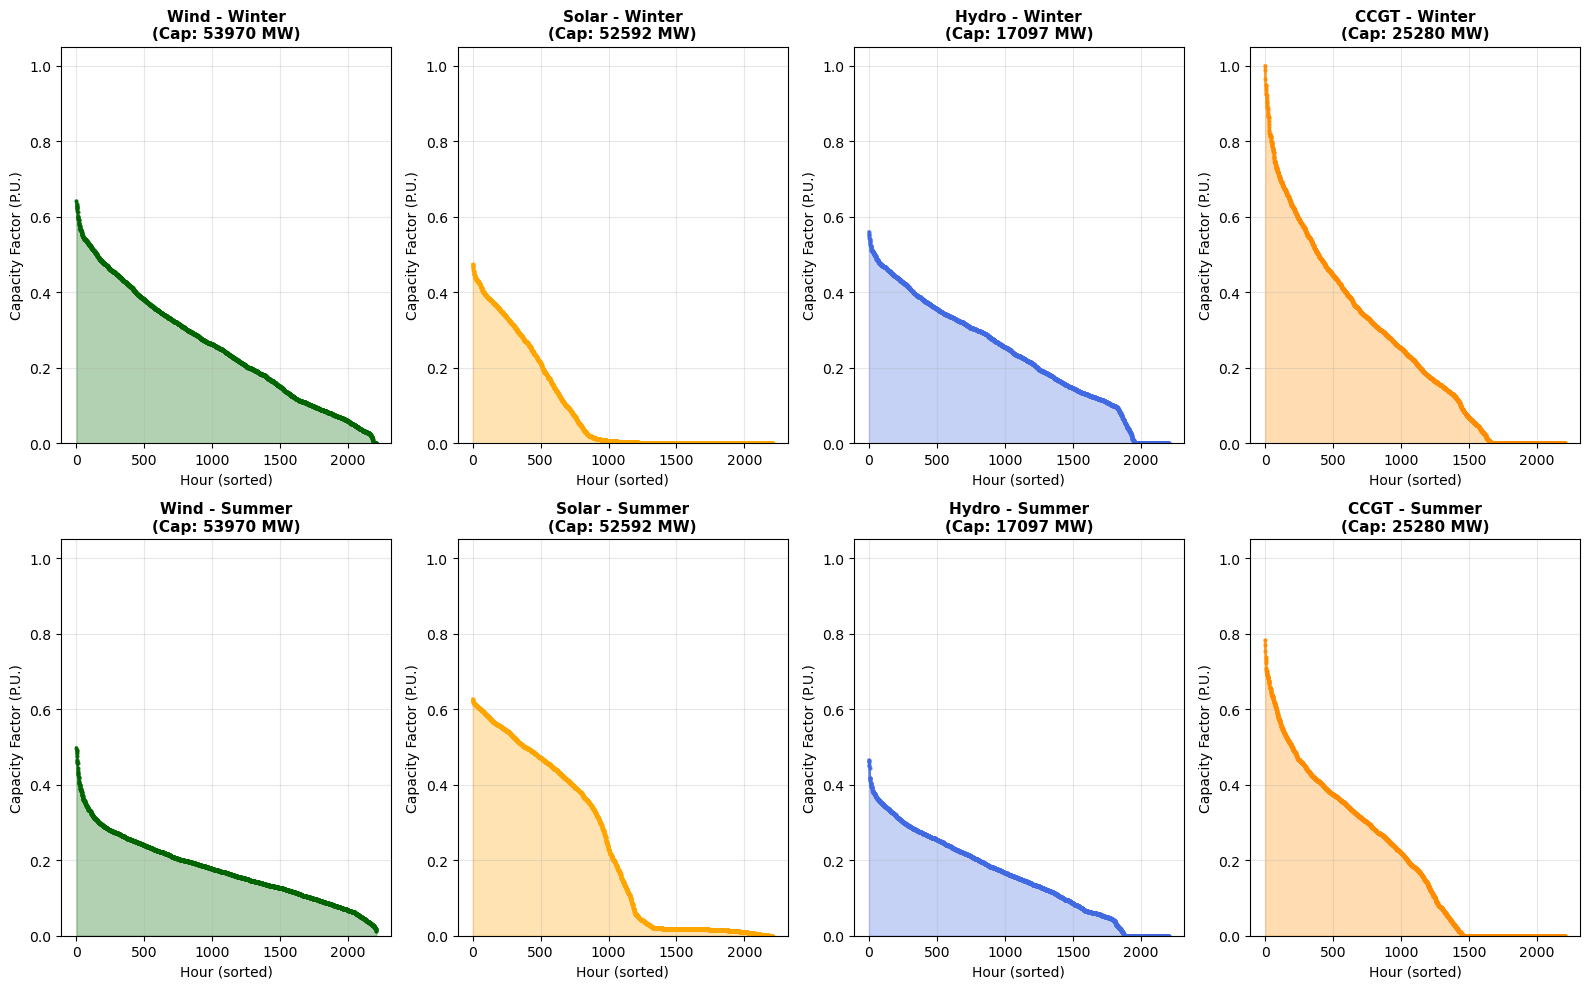


P.U. LOAD CURVE STATISTICS BY TECHNOLOGY (FULL SEASON)


WINTER SEASON:
------------------------------------------------------------------------------------------
Period: 2024-01-01 to 2025-01-01 (2208 hours)

Wind         | Avg P.U.: 0.250 | Peak P.U.: 0.641 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 53970 MW
Solar        | Avg P.U.: 0.094 | Peak P.U.: 0.474 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 52592 MW
Hydro        | Avg P.U.: 0.232 | Peak P.U.: 0.560 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 17097 MW
CCGT         | Avg P.U.: 0.256 | Peak P.U.: 1.000 | Min P.U.: 0.000 | Hours at full: 3 h | Cap: 25280 MW

SUMMER SEASON:
------------------------------------------------------------------------------------------
Period: 2024-06-01 to 2024-08-31 (2208 hours)

Wind         | Avg P.U.: 0.174 | Peak P.U.: 0.498 | Min P.U.: 0.012 | Hours at full: 0 h | Cap: 53970 MW
Solar        | Avg P.U.: 0.231 | Peak P.U.: 0.627 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 52592 MW
Hydro

In [40]:
# === Technology Load Curves - Per Unit (P.U.) Load Duration Curves ===
print("\n" + "="*70)
print("TECHNOLOGY LOAD DURATION CURVES - FULL SEASON (P.U. SORTED MAX TO MIN)")
print("="*70)

season_months = {'Winter': [12, 1, 2], 'Summer': [6, 7, 8]}
solution_df = result.solution
color_map = {
    'Wind': 'darkgreen', 'Solar': 'orange', 'Hydro': 'royalblue',
    'Coal': 'darkred', 'Nuclear': 'purple', 'CCGT': 'darkorange'
}

# Exclude technologies with 0 capacity
techs_to_plot = [t for t in tech_params_opt.keys() if t in solution_df.columns and result.optimal_capacities.get(t, 0) > 0]
n_techs = len(techs_to_plot)

# Create subplots: rows=seasons, cols=techs
fig, axes = plt.subplots(2, n_techs, figsize=(4*n_techs, 10))
if n_techs == 1:
    axes = axes.reshape(2, 1)

for season_idx, (season, months) in enumerate(season_months.items()):
    # Filter for entire season
    season_idx_bool = np.array(solution_df.index.month.isin(months))
    season_data = solution_df.iloc[season_idx_bool].copy()
    
    # Plot each technology individually in P.U.
    for tech_idx, tech in enumerate(techs_to_plot):
        ax = axes[season_idx, tech_idx]
        
        # Get capacity and normalize to P.U.
        capacity = result.optimal_capacities.get(tech, 1)
        gen_pu = season_data[tech].values / capacity if capacity > 0 else season_data[tech].values
        
        # Sort P.U. values from max to min
        sorted_pu = np.sort(gen_pu)[::-1]
        
        # Plot technology generation in P.U.
        ax.plot(range(len(sorted_pu)), sorted_pu, 
                color=color_map.get(tech, 'gray'), linewidth=2, marker='o', markersize=2, alpha=0.8)
        ax.fill_between(range(len(sorted_pu)), sorted_pu, alpha=0.3, 
                        color=color_map.get(tech, 'gray'))
        
        # Set limits for P.U. to 0-1
        ax.set_ylim([0, 1.05])
        ax.set_title(f"{tech} - {season}\n(Cap: {capacity:.0f} MW)", 
                    fontsize=11, fontweight='bold')
        ax.set_ylabel('Capacity Factor (P.U.)', fontsize=10)
        ax.set_xlabel('Hour (sorted)', fontsize=10)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print P.U. load curve statistics
print("\n" + "="*70)
print("P.U. LOAD CURVE STATISTICS BY TECHNOLOGY (FULL SEASON)")
print("="*70 + "\n")

for season, months in season_months.items():
    print(f"\n{season.upper()} SEASON:")
    print("-" * 90)
    
    season_idx_bool = np.array(solution_df.index.month.isin(months))
    season_data = solution_df.iloc[season_idx_bool]
    
    print(f"Period: {season_data.index[0].strftime('%Y-%m-%d')} to {season_data.index[-1].strftime('%Y-%m-%d')} ({len(season_data)} hours)\n")
    
    for tech in techs_to_plot:
        if tech in season_data.columns:
            capacity = result.optimal_capacities.get(tech, 1)
            gen_pu = season_data[tech].values / capacity if capacity > 0 else season_data[tech].values
            
            print(f"{tech:12s} | Avg P.U.: {gen_pu.mean():.3f} | Peak P.U.: {gen_pu.max():.3f} | "
                  f"Min P.U.: {gen_pu.min():.3f} | Hours at full: {(gen_pu >= 0.95).sum()} h | Cap: {capacity:.0f} MW")


ANNUAL ELECTRICITY MIX

Total Annual Generation: 248,792.0 GWh



,Technology,Generation (GWh),Share (%)
0,Wind,"101,247.0",40.7%
1,Solar,"72,443.7",29.1%
2,CCGT,"43,346.5",17.4%
3,Hydro,"31,754.8",12.8%


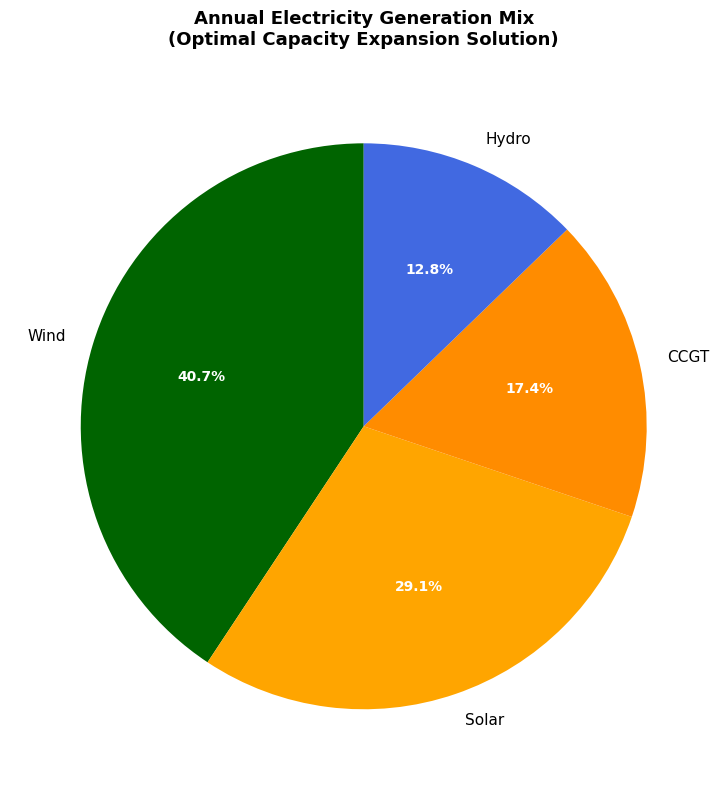

In [41]:
# === Annual Electricity Mix ===
print("\n" + "="*70)
print("ANNUAL ELECTRICITY MIX")
print("="*70)

# Calculate total generation by technology for the entire year
annual_generation = {}
for tech in techs_to_plot:
    if tech in solution_df.columns:
        total_gen = solution_df[tech].sum()
        annual_generation[tech] = total_gen

# Filter out technologies with 0 generation
annual_generation_nonzero = {tech: gen for tech, gen in annual_generation.items() if gen > 0}

# Total generation (GWh)
total_gen_mwh = sum(annual_generation_nonzero.values())
total_gen_gwh = total_gen_mwh / 1000

# Create generation summary table (only non-zero)
gen_summary = []
for tech in sorted(annual_generation_nonzero.keys(), key=lambda t: annual_generation_nonzero[t], reverse=True):
    gen_mwh = annual_generation_nonzero[tech]
    gen_gwh = gen_mwh / 1000
    pct = (gen_mwh / total_gen_mwh * 100) if total_gen_mwh > 0 else 0
    
    gen_summary.append({
        'Technology': tech,
        'Generation (GWh)': f"{gen_gwh:,.1f}",
        'Share (%)': f"{pct:.1f}%",
    })

print(f"\nTotal Annual Generation: {total_gen_gwh:,.1f} GWh\n")
gen_summary_df = pd.DataFrame(gen_summary)
display(gen_summary_df)

# Plot pie chart of electricity mix (only non-zero generation)
fig, ax = plt.subplots(figsize=(10, 8))

# Sort by generation for better visualization
sorted_techs = sorted(annual_generation_nonzero.keys(), key=lambda t: annual_generation_nonzero[t], reverse=True)
gen_values = [annual_generation_nonzero[tech] / 1000 for tech in sorted_techs]  # Convert to GWh
colors_pie = [color_map.get(tech, 'gray') for tech in sorted_techs]

# Create pie chart
wedges, texts, autotexts = ax.pie(gen_values, labels=sorted_techs, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90, textprops={'fontsize': 11})

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Annual Electricity Generation Mix\n(Optimal Capacity Expansion Solution)', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Battery Storage Integration

## Battery and Hydrogen Storage Optimization Model

### Sets and Indices
- $T$ = Set of technologies (Wind, Solar, Hydro, CCGT, Coal, Nuclear)
- $H$ = Set of hourly time steps ($h = 1, 2, ..., 8760$)
- $D$ = Set of days ($d = 1, 2, ..., 365$)

### Storage Decision Variables
- $P_{bat}^{nom}$ = Battery power capacity (MW) — **extensible (optimized)**
- $E_{bat}^{nom}$ = Battery energy capacity (MWh) — **extensible (optimized)**
- $P_{h2}^{nom}$ = Hydrogen power capacity (MW) — **extensible (optimized)**
- $E_{h2}^{nom}$ = Hydrogen energy capacity (MWh) — **extensible (optimized)**

### Hourly Storage Variables
- $P_{bat,h}^{ch}$ = Battery charging power at hour $h$ (MW) — non-negative
- $P_{bat,h}^{dis}$ = Battery discharging power at hour $h$ (MW) — non-negative
- $SOC_{bat,h}$ = Battery state of charge at hour $h$ (MWh) — continuous
- $P_{h2,h}^{ch}$ = Hydrogen electrolyzing power at hour $h$ (MW) — non-negative
- $P_{h2,h}^{dis}$ = Hydrogen fuel cell power at hour $h$ (MW) — non-negative
- $SOC_{h2,h}$ = Hydrogen state of charge at hour $h$ (MWh) — continuous

### Storage Parameters
| Parameter | Symbol | Value | Description |
|-----------|--------|-------|-------------|
| Battery max duration | $\tau_{bat}$ | 4 hours | Default storage duration |
| Battery charging efficiency | $\eta_{bat}^{ch}$ | 0.95 | Charging efficiency (0-1) |
| Battery discharging efficiency | $\eta_{bat}^{dis}$ | 0.9 | Discharging efficiency (0-1) |
| Battery standing loss | $\lambda_{bat}$ | 0.0 | Hourly energy loss (0-1) |
| Hydrogen max duration | $\tau_{h2}$ | 168 hours | ~1 week weekly storage |
| Hydrogen electrolyzer efficiency | $\eta_{h2}^{ch}$ | $\sqrt{\eta_{h2}^{RT}}$ ≈ 0.632 | Electrolyzer efficiency |
| Hydrogen fuel cell efficiency | $\eta_{h2}^{dis}$ | $\sqrt{\eta_{h2}^{RT}}$ ≈ 0.632 | Fuel cell efficiency |
| Hydrogen standing loss | $\lambda_{h2}$ | 0.0 | Hourly energy loss (0-1) |

### Objective Function (Extended)

Minimize total annual system cost:
$$\min Z = \sum_{t \in T} FC_t \cdot C_t + \sum_{t \in T} \sum_{h \in H} VC_t \cdot G_{t,h} + FC_{bat} \cdot P_{bat}^{nom} + FC_{h2} \cdot P_{h2}^{nom}$$

where:
- $FC_{bat}$ = Battery fixed cost (€/MW/year)
- $FC_{h2}$ = Hydrogen fixed cost (€/MW/year)

### Battery Storage Constraints

**1. Energy Capacity Limit:**
$$E_{bat}^{nom} = P_{bat}^{nom} \times \tau_{bat}$$

**2. State of Charge Dynamics:**
$$SOC_{bat,h} = SOC_{bat,h-1} \cdot (1 - \lambda_{bat}) + P_{bat,h}^{ch} \cdot \eta_{bat}^{ch} - \frac{P_{bat,h}^{dis}}{\eta_{bat}^{dis}} \quad \forall h \in H$$

**3. SOC Limits:**
$$0 \leq SOC_{bat,h} \leq E_{bat}^{nom} \quad \forall h \in H$$

**4. Charging Power Limit:**
$$P_{bat,h}^{ch} \leq P_{bat}^{nom} \quad \forall h \in H$$

**5. Discharging Power Limit:**
$$P_{bat,h}^{dis} \leq P_{bat}^{nom} \quad \forall h \in H$$

**6. Daily Cyclic Constraint (SOC Reset at Day Boundaries):**
$$SOC_{bat,24 \cdot d} = SOC_{bat,0} = 0.25 \cdot E_{bat}^{nom} \quad \forall d \in D$$

This constraint ensures the battery operates in a day-ahead mode: it starts each day with 25% charge and ends at 25% charge, allowing 75% of capacity for daily arbitrage.

### Hydrogen Storage Constraints

**1. Energy Capacity Limit:**
$$E_{h2}^{nom} = P_{h2}^{nom} \times \tau_{h2}$$

**2. State of Charge Dynamics:**
$$SOC_{h2,h} = SOC_{h2,h-1} \cdot (1 - \lambda_{h2}) + P_{h2,h}^{ch} \cdot \eta_{h2}^{ch} - \frac{P_{h2,h}^{dis}}{\eta_{h2}^{dis}} \quad \forall h \in H$$

**3. SOC Limits:**
$$0 \leq SOC_{h2,h} \leq E_{h2}^{nom} \quad \forall h \in H$$

**4. Charging Power Limit:**
$$P_{h2,h}^{ch} \leq P_{h2}^{nom} \quad \forall h \in H$$

**5. Discharging Power Limit:**
$$P_{h2,h}^{dis} \leq P_{h2}^{nom} \quad \forall h \in H$$

**6. Initial SOC Constraint (Weekly Reset):**
$$SOC_{h2,0} = SOC_{h2,168} = SOC_{h2,336} = ... = 0.25 \cdot E_{h2}^{nom}$$

Unlike battery, hydrogen does NOT reset daily. It maintains a longer-term cycle (weekly), allowing multi-day storage for seasonal balancing.

### Updated Power Balance Constraint

$$\sum_{t \in T} G_{t,h} + P_{bat,h}^{dis} + P_{h2,h}^{dis} = D_h + P_{bat,h}^{ch} + P_{h2,h}^{ch} \quad \forall h \in H$$

### Key Operational Features

1. **Battery (4-hour storage):**
   - High round-trip efficiency (~81% = 0.9²)
   - Daily cyclic constraint maintains 25% base-load
   - Suitable for intra-day smoothing and peak-shaving
   - Rapid response capability

2. **Hydrogen (1-week storage):**
   - Lower round-trip efficiency (~40% = 0.632²)
   - Weekly cyclic constraint allows multi-day patterns
   - Suitable for seasonal energy arbitrage
   - Slower response but higher energy density

3. **Joint Optimization:**
   - Optimizer selects optimal mix of battery + hydrogen
   - Can choose: battery only, hydrogen only, both, or neither
   - Complementary roles: battery handles frequencies > 1 day, hydrogen 
   handles < 1 day


CAPACITY EXPANSION WITH BATTERY AND HYDROGEN STORAGE (JOINT OPTIMIZATION)
Storage technology parameters from CSV:

Battery system:
  Overnight cost: €450/kWel
  FOM: 2.0%/year
  Annualized fixed cost: €9000.0/MW/year
  Round-trip efficiency: 90%
  Charging efficiency: 0.949
  Discharging efficiency: 0.949

Hydrogen system:
  Overnight cost: €2800/kWel
  FOM: 3.0%/year
  Annualized fixed cost: €84000.0/MW/year
  Round-trip efficiency: 35%
  Electrolyzer efficiency: 0.592
  Fuel cell efficiency: 0.592



d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment\python_codes\Abstract_model.py:620: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  network.storage_units_t.state_of_charge_set[storage_name].iloc[hour_index] = soc_target
d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment\python_codes\Abstract_model.py:626: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set

  Setting battery initial SOC = 25% with daily resets
    → e_nom_max: 200,000 MWh, SOC_initial target: 0 MWh (25%)
  Setting hydrogen initial SOC = 25% with daily resets
    → e_nom_max: 8,400,000 MWh, SOC_initial target: 0 MWh (25%)

Optimizing capacity expansion with battery storage using gurobi...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 94.55it/s]
INFO:linopy.io: Writing time: 0.49s


Set parameter Username


...

✓ Optimization complete

  Extracting results:
    Technologies: [('Wind', '40169 MW'), ('Solar', '89319 MW'), ('Hydro', '17097 MW'), ('CCGT', '16476 MW'), ('Coal', '0 MW'), ('Nuclear', '0 MW')]
    Battery power: 31180 MW / 124719 MWh
    Hydrogen power: 0 MW / 0 MWh

  [DEBUG] p_nom_opt values (optimized capacity):
  [DEBUG] Battery p_nom_opt: 31179.74 MW
  [DEBUG] Hydrogen p_nom_opt: 0.00 MW

Status: optimal
Total annual cost: €4,346,382,273

OPTIMAL CAPACITIES (JOINT OPTIMIZATION: BATTERY + HYDROGEN)

Generation & Storage Capacities:


,Technology,Power Capacity (MW)
0,Wind,40168.724958
1,Solar,89318.909857
2,Hydro,17096.959000
3,CCGT,16475.713826
4,Coal,0.000000
5,Nuclear,0.000000
6,Battery,31179.742242
7,Hydrogen,0.000000



Storage Capacities:
  Battery: 31,180 MW / 124,719 MWh (4-hour duration)
  Hydrogen: 0 MW / 0 MWh (weekly duration)

COST BREAKDOWN (JOINT OPTIMIZATION)



,Technology,Fixed Cost (€),Variable Cost (€),Total (€)
3,CCGT,"263,611,421","740,706,812","1,004,318,233"
4,Coal,0,0,0
2,Hydro,"341,939,180",0,"341,939,180"
5,Nuclear,0,0,0
1,Solar,"1,295,124,193",0,"1,295,124,193"
0,Wind,"1,424,382,987",0,"1,424,382,987"
6,battery,"280,617,680",0,"280,617,680"
7,hydrogen,0,0,0



STORAGE DEPLOYMENT SUMMARY

✓ BATTERY ONLY SELECTED: 31180 MW / 124719 MWh

Battery role:
  - Daily peak-shaving and demand arbitrage
  - High round-trip efficiency minimizes energy loss
  - Supports renewable smoothing during intra-day variations

GENERATION MIX WITH STORAGE (REPRESENTATIVE WEEK)


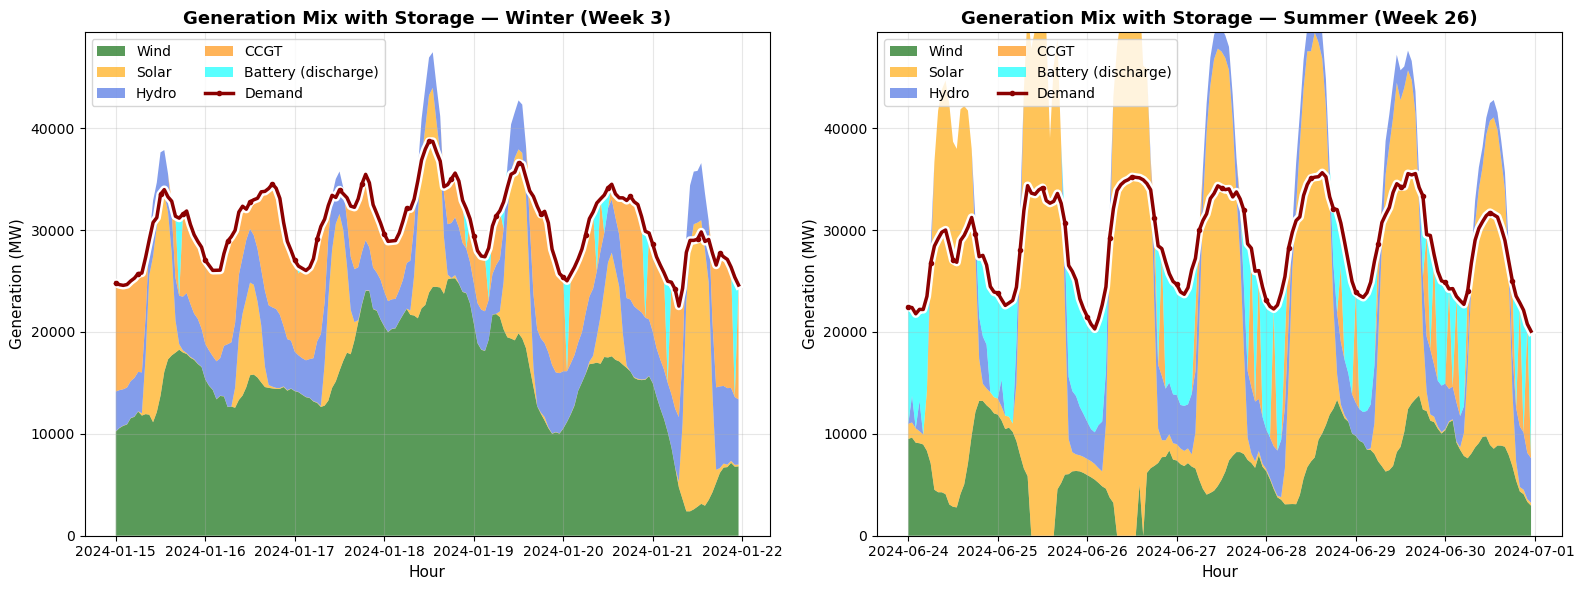


STORAGE STATE OF CHARGE PROFILES


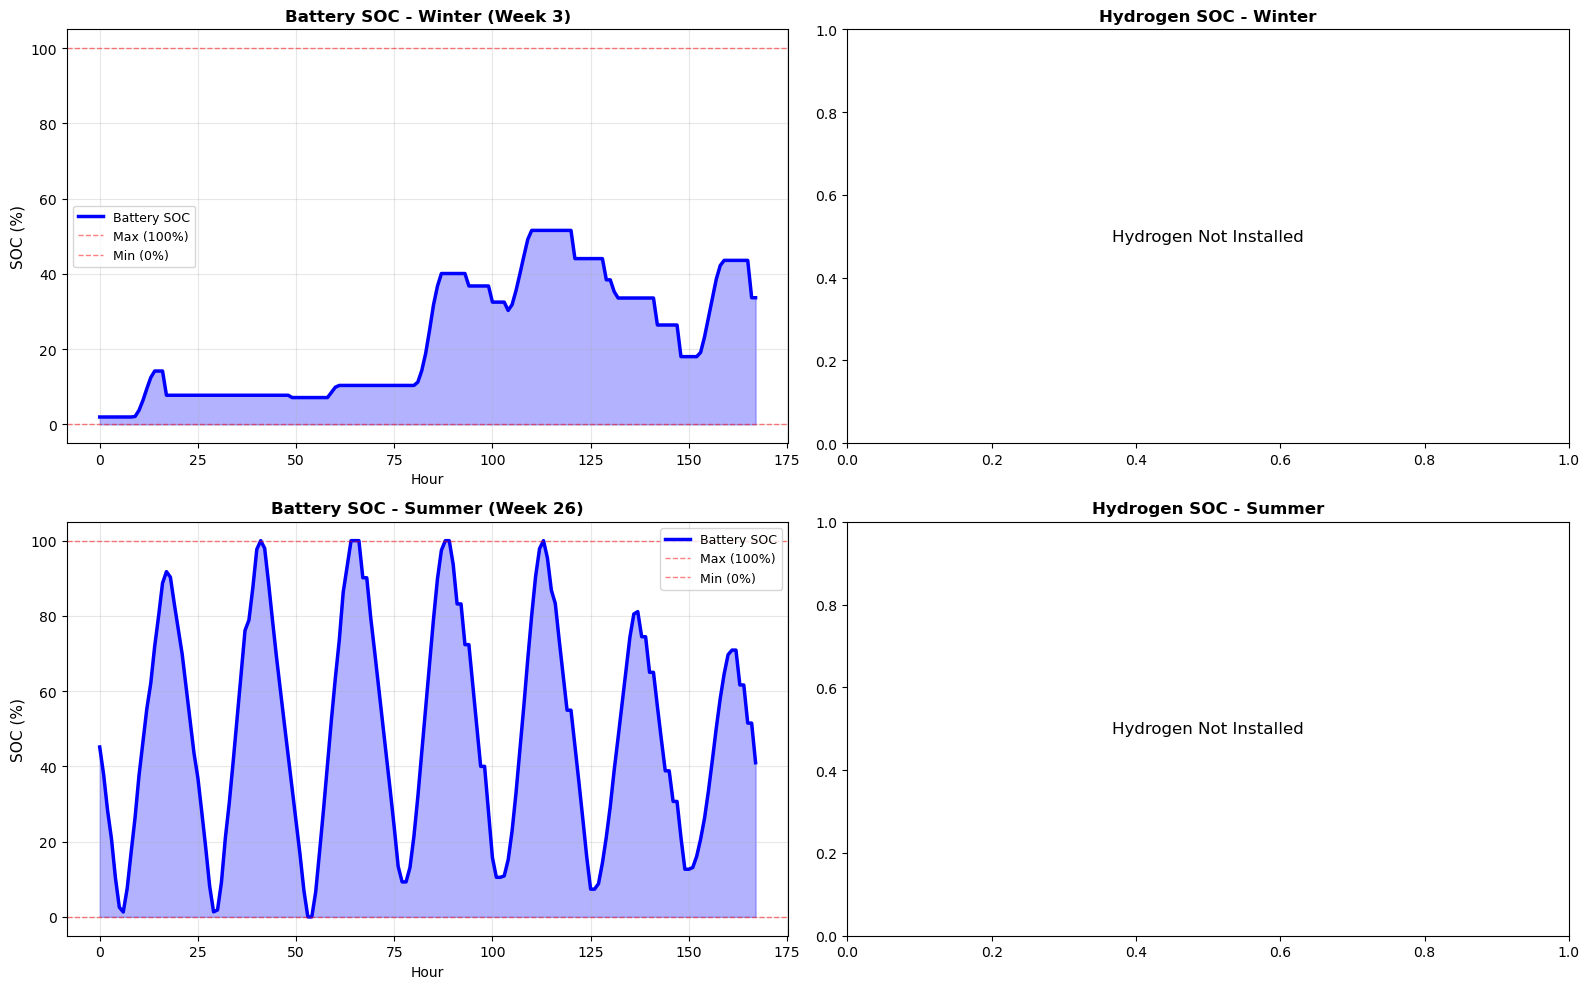


STORAGE STATE OF CHARGE STATISTICS (REPRESENTATIVE WEEKS)

WINTER (Week 3):
  Battery: Avg SOC = 22.7%, Min = 2.0%, Max = 51.6%

SUMMER (Week 26):
  Battery: Avg SOC = 50.0%, Min = 0.0%, Max = 100.0%


In [42]:
# === CAPACITY EXPANSION WITH BATTERY AND HYDROGEN STORAGE (JOINT OPTIMIZATION) ===
print("\n" + "="*70)
print("CAPACITY EXPANSION WITH BATTERY AND HYDROGEN STORAGE (JOINT OPTIMIZATION)")
print("="*70)

# Reload module to get updated function
pycache_dir = module_dir / "__pycache__"
if pycache_dir.exists():
    shutil.rmtree(pycache_dir)

mods_to_remove = [mod for mod in sys.modules if 'Abstract_model' in mod]
for mod in mods_to_remove:
    del sys.modules[mod]

from python_codes.Abstract_model import optimize_capacity_expansion_with_storage

# Load the CSV with storage costs (includes Battery and Hydrogen system rows)
cost_df_storage = pd.read_csv('./Data/Techs_&_storage_cost_FOM_&_Fuel_cost.csv')

# Extract battery costs from CSV
battery_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Battery system'].iloc[0]
battery_overnight_cost = battery_tech_row['Overnight Cost']  # €/kWel
battery_fom = battery_tech_row['FOM (%/a)'] / 100.0
battery_efficiency = battery_tech_row['Efficiency']
battery_fixed_cost = battery_overnight_cost * 1000 * battery_fom  # €/MW/year

# Extract hydrogen costs from CSV
hydrogen_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Hydrogen system'].iloc[0]
hydrogen_overnight_cost = hydrogen_tech_row['Overnight Cost']  # €/kWel
hydrogen_fom = hydrogen_tech_row['FOM (%/a)'] / 100.0
hydrogen_efficiency = hydrogen_tech_row['Efficiency']
hydrogen_fixed_cost = hydrogen_overnight_cost * 1000 * hydrogen_fom  # €/MW/year

print(f"Storage technology parameters from CSV:")
print(f"\nBattery system:")
print(f"  Overnight cost: €{battery_overnight_cost:.0f}/kWel")
print(f"  FOM: {battery_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{battery_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {battery_efficiency*100:.0f}%")
print(f"  Charging efficiency: {battery_efficiency**0.5:.3f}")
print(f"  Discharging efficiency: {battery_efficiency**0.5:.3f}")

print(f"\nHydrogen system:")
print(f"  Overnight cost: €{hydrogen_overnight_cost:.0f}/kWel")
print(f"  FOM: {hydrogen_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{hydrogen_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {hydrogen_efficiency*100:.0f}%")
print(f"  Electrolyzer efficiency: {hydrogen_efficiency**0.5:.3f}")
print(f"  Fuel cell efficiency: {hydrogen_efficiency**0.5:.3f}\n")

# Run joint optimization with both battery and hydrogen
result_with_storage = optimize_capacity_expansion_with_storage(
    data=data,
    # Battery parameters
    battery_max_hours=4.0,
    battery_charging_efficiency=battery_efficiency**0.5,
    battery_discharging_efficiency=battery_efficiency**0.5,
    battery_standing_loss=0.0,
    battery_fixed_cost=battery_fixed_cost,
    battery_variable_cost=0.0,
    battery_max_capacity_limit=50000.0,
    # Hydrogen parameters
    hydrogen_max_hours=168.0,  # 1 week storage
    hydrogen_charging_efficiency=hydrogen_efficiency**0.5,
    hydrogen_discharging_efficiency=hydrogen_efficiency**0.5,
    hydrogen_standing_loss=0.0,
    hydrogen_fixed_cost=hydrogen_fixed_cost,
    hydrogen_variable_cost=0.0,
    hydrogen_max_capacity_limit=50000.0,
    solver_name="gurobi",
)

print(f"Status: {result_with_storage.status}")
print(f"Total annual cost: €{result_with_storage.objective_value:,.0f}\n")

# === Results: Capacity Table WITH BATTERY AND HYDROGEN ===
print("="*70)
print("OPTIMAL CAPACITIES (JOINT OPTIMIZATION: BATTERY + HYDROGEN)")
print("="*70)

storage_capacity_table = pd.DataFrame({
    'Technology': list(tech_params_opt.keys()) + ['Battery', 'Hydrogen'],
    'Power Capacity (MW)': [result_with_storage.optimal_capacities.get(tech, 0) for tech in tech_params_opt.keys()] + 
                           [result_with_storage.optimal_capacities.get('battery_power', 0),
                            result_with_storage.optimal_capacities.get('hydrogen_power', 0)],
})

print("\nGeneration & Storage Capacities:")
display(storage_capacity_table)

battery_energy = result_with_storage.optimal_capacities.get('battery_energy', 0)
hydrogen_energy = result_with_storage.optimal_capacities.get('hydrogen_energy', 0)

print(f"\nStorage Capacities:")
print(f"  Battery: {result_with_storage.optimal_capacities.get('battery_power', 0):,.0f} MW / {battery_energy:,.0f} MWh (4-hour duration)")
print(f"  Hydrogen: {result_with_storage.optimal_capacities.get('hydrogen_power', 0):,.0f} MW / {hydrogen_energy:,.0f} MWh (weekly duration)\n")

# === Cost breakdown WITH BATTERY AND HYDROGEN ===
print("="*70)
print("COST BREAKDOWN (JOINT OPTIMIZATION)")
print("="*70)

cost_summary_storage = []
for tech, costs in result_with_storage.technology_costs.items():
    cost_summary_storage.append({
        'Technology': tech,
        'Fixed Cost (€)': f"{costs['fixed_cost']:,.0f}",
        'Variable Cost (€)': f"{costs['variable_cost']:,.0f}",
        'Total (€)': f"{costs['total']:,.0f}",
    })

cost_summary_storage_df = pd.DataFrame(cost_summary_storage).sort_values('Technology')
print()
display(cost_summary_storage_df)

# Check storage deployment
battery_power_nom = result_with_storage.optimal_capacities.get('battery_power', 0)
hydrogen_power_nom = result_with_storage.optimal_capacities.get('hydrogen_power', 0)

print("\n" + "="*70)
print("STORAGE DEPLOYMENT SUMMARY")
print("="*70)

if battery_power_nom == 0 and hydrogen_power_nom == 0:
    print("\n✗ NO STORAGE SELECTED (Battery and Hydrogen both economically unfavorable)")
    print("\nThis is typical when:")
    print("  - Renewable generation is sufficient to meet demand")
    print("  - Thermal generators (CCGT, Coal) can flexibly ramp up/down")
    print("  - Storage capital costs exceed savings from peak shaving")
    print("  - Time-of-use price arbitrage is limited\n")
elif battery_power_nom > 0 and hydrogen_power_nom == 0:
    print(f"\n✓ BATTERY ONLY SELECTED: {battery_power_nom:.0f} MW / {battery_energy:.0f} MWh")
    print("\nBattery role:")
    print("  - Daily peak-shaving and demand arbitrage")
    print("  - High round-trip efficiency minimizes energy loss")
    print("  - Supports renewable smoothing during intra-day variations\n")
elif battery_power_nom == 0 and hydrogen_power_nom > 0:
    print(f"\n✓ HYDROGEN ONLY SELECTED: {hydrogen_power_nom:.0f} MW / {hydrogen_energy:.0f} MWh")
    print("\nHydrogen role:")
    print("  - Long-term multi-day/weekly storage")
    print("  - Seasonal energy arbitrage")
    print("  - Can smooth longer-duration renewable droughts\n")
else:
    print(f"\n✓ BOTH STORAGE TYPES SELECTED (Optimal mix):")
    print(f"   Battery:  {battery_power_nom:.0f} MW / {battery_energy:.0f} MWh (daily peak-shaving)")
    print(f"   Hydrogen: {hydrogen_power_nom:.0f} MW / {hydrogen_energy:.0f} MWh (weekly/seasonal storage)")
    print("\nComplementary roles:")
    print("  - Battery handles high-frequency intra-day variations (efficiency 90%+)")
    print("  - Hydrogen handles lower-frequency multi-day variations (efficiency ~40%)")
    print("  - Combined system optimizes across all timescales\n")

# === Generation mix with both storage types (representative week) ===
if battery_power_nom > 0 or hydrogen_power_nom > 0:
    print("="*70)
    print("GENERATION MIX WITH STORAGE (REPRESENTATIVE WEEK)")
    print("="*70)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    solution_with_storage = result_with_storage.solution

    techs_with_storage = [t for t in tech_params_opt.keys() if t in solution_with_storage.columns and result_with_storage.optimal_capacities.get(t, 0) > 0]

    for idx, (season, week_num) in enumerate(representative_weeks.items()):
        week_start = (week_num - 1) * 168
        week_end = week_start + 168
        week_data = solution_with_storage.iloc[week_start:week_end]

        plot_data = week_data[techs_with_storage].copy()
        colors = [color_map.get(t, 'gray') for t in techs_with_storage]

        if battery_power_nom > 0 and 'battery_discharge' in week_data.columns:
            plot_data['Battery (discharge)'] = week_data['battery_discharge']
            colors.append('cyan')

        if hydrogen_power_nom > 0 and 'hydrogen_discharge' in week_data.columns:
            plot_data['H₂ (discharge)'] = week_data['hydrogen_discharge']
            colors.append('magenta')

        ax = axes[idx]
        x = week_data.index

        # stacked area with matplotlib
        ax.stackplot(
            x,
            *[plot_data[col].values for col in plot_data.columns],
            labels=plot_data.columns,
            colors=colors,
            alpha=0.65,
            zorder=1
        )

        # demand line on top
        ax.plot(
            x,
            week_data['demand'].values,
            color='white',
            linewidth=6,
            zorder=10
        )

        ax.plot(
            x,
            week_data['demand'].values,
            color='darkred',
            linewidth=2.5,
            marker='o',
            markersize=3,
            markevery=6,
            label='Demand',
            zorder=11
        )

        ax.set_title(f"Generation Mix with Storage — {season} (Week {week_num})",
                    fontsize=13, fontweight='bold')
        ax.set_ylabel('Generation (MW)', fontsize=11)
        ax.set_xlabel('Hour', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, demand_yearly.max() * 1.2)

        ax.legend(loc='upper left', fontsize=10, ncol=2)

    plt.tight_layout()
    plt.show()

    # === Storage State of Charge (SOC) Comparison ===
    print("\n" + "="*70)
    print("STORAGE STATE OF CHARGE PROFILES")
    print("="*70)

    solution_with_storage = result_with_storage.solution
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot SOC for representative weeks (same as generation mix)
    for idx, (season, week_num) in enumerate(representative_weeks.items()):
        week_start = (week_num - 1) * 168
        week_end = week_start + 168
        
        # Battery SOC
        if battery_power_nom > 0 and 'battery_soc' in solution_with_storage.columns:
            battery_soc = solution_with_storage['battery_soc'].iloc[week_start:week_end]
            soc_percent = 100 * battery_soc / battery_energy if battery_energy > 0 else battery_soc * 0
            
            axes[idx, 0].plot(range(len(soc_percent)), soc_percent.values, color='blue', linewidth=2.5, label='Battery SOC')
            axes[idx, 0].fill_between(range(len(soc_percent)), soc_percent.values, alpha=0.3, color='blue')
            axes[idx, 0].axhline(y=100, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Max (100%)')
            axes[idx, 0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Min (0%)')
            
            axes[idx, 0].set_title(f'Battery SOC - {season} (Week {week_num})', fontsize=12, fontweight='bold')
            axes[idx, 0].set_ylabel('SOC (%)', fontsize=11)
            axes[idx, 0].set_ylim([-5, 105])
            axes[idx, 0].legend(fontsize=9)
            axes[idx, 0].grid(True, alpha=0.3)
            axes[idx, 0].set_xlabel('Hour')
        else:
            axes[idx, 0].text(0.5, 0.5, 'Battery Not Installed', ha='center', va='center', fontsize=12)
            axes[idx, 0].set_title(f'Battery SOC - {season}', fontsize=12, fontweight='bold')
        
        # Hydrogen SOC
        if hydrogen_power_nom > 0 and 'hydrogen_soc' in solution_with_storage.columns:
            hydrogen_soc = solution_with_storage['hydrogen_soc'].iloc[week_start:week_end]
            soc_percent_h2 = 100 * hydrogen_soc / hydrogen_energy if hydrogen_energy > 0 else hydrogen_soc * 0
            
            axes[idx, 1].plot(range(len(soc_percent_h2)), soc_percent_h2.values, color='red', linewidth=2.5, label='Hydrogen SOC')
            axes[idx, 1].fill_between(range(len(soc_percent_h2)), soc_percent_h2.values, alpha=0.3, color='red')
            axes[idx, 1].axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Max (100%)')
            axes[idx, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Min (0%)')
            
            axes[idx, 1].set_title(f'Hydrogen SOC - {season} (Week {week_num})', fontsize=12, fontweight='bold')
            axes[idx, 1].set_ylabel('SOC (%)', fontsize=11)
            axes[idx, 1].set_xlabel('Hour', fontsize=11)
            axes[idx, 1].set_ylim([-5, 105])
            axes[idx, 1].legend(fontsize=9)
            axes[idx, 1].grid(True, alpha=0.3)
        else:
            axes[idx, 1].text(0.5, 0.5, 'Hydrogen Not Installed', ha='center', va='center', fontsize=12)
            axes[idx, 1].set_title(f'Hydrogen SOC - {season}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print SOC statistics for representative weeks
    print("\n" + "="*70)
    print("STORAGE STATE OF CHARGE STATISTICS (REPRESENTATIVE WEEKS)")
    print("="*70)
    
    for season, week_num in representative_weeks.items():
        week_start = (week_num - 1) * 168
        week_end = week_start + 168
        
        print(f"\n{season.upper()} (Week {week_num}):")
        
        if battery_power_nom > 0 and 'battery_soc' in solution_with_storage.columns:
            battery_soc = solution_with_storage['battery_soc'].iloc[week_start:week_end]
            soc_percent = 100 * battery_soc / battery_energy if battery_energy > 0 else battery_soc * 0
            print(f"  Battery: Avg SOC = {soc_percent.mean():.1f}%, Min = {soc_percent.min():.1f}%, Max = {soc_percent.max():.1f}%")
        
        if hydrogen_power_nom > 0 and 'hydrogen_soc' in solution_with_storage.columns:
            hydrogen_soc = solution_with_storage['hydrogen_soc'].iloc[week_start:week_end]
            soc_percent_h2 = 100 * hydrogen_soc / hydrogen_energy if hydrogen_energy > 0 else hydrogen_soc * 0
            print(f"  Hydrogen: Avg SOC = {soc_percent_h2.mean():.1f}%, Min = {soc_percent_h2.min():.1f}%, Max = {soc_percent_h2.max():.1f}%")



TECHNOLOGY LOAD DURATION CURVES - FULL SEASON (P.U. SORTED MAX TO MIN)


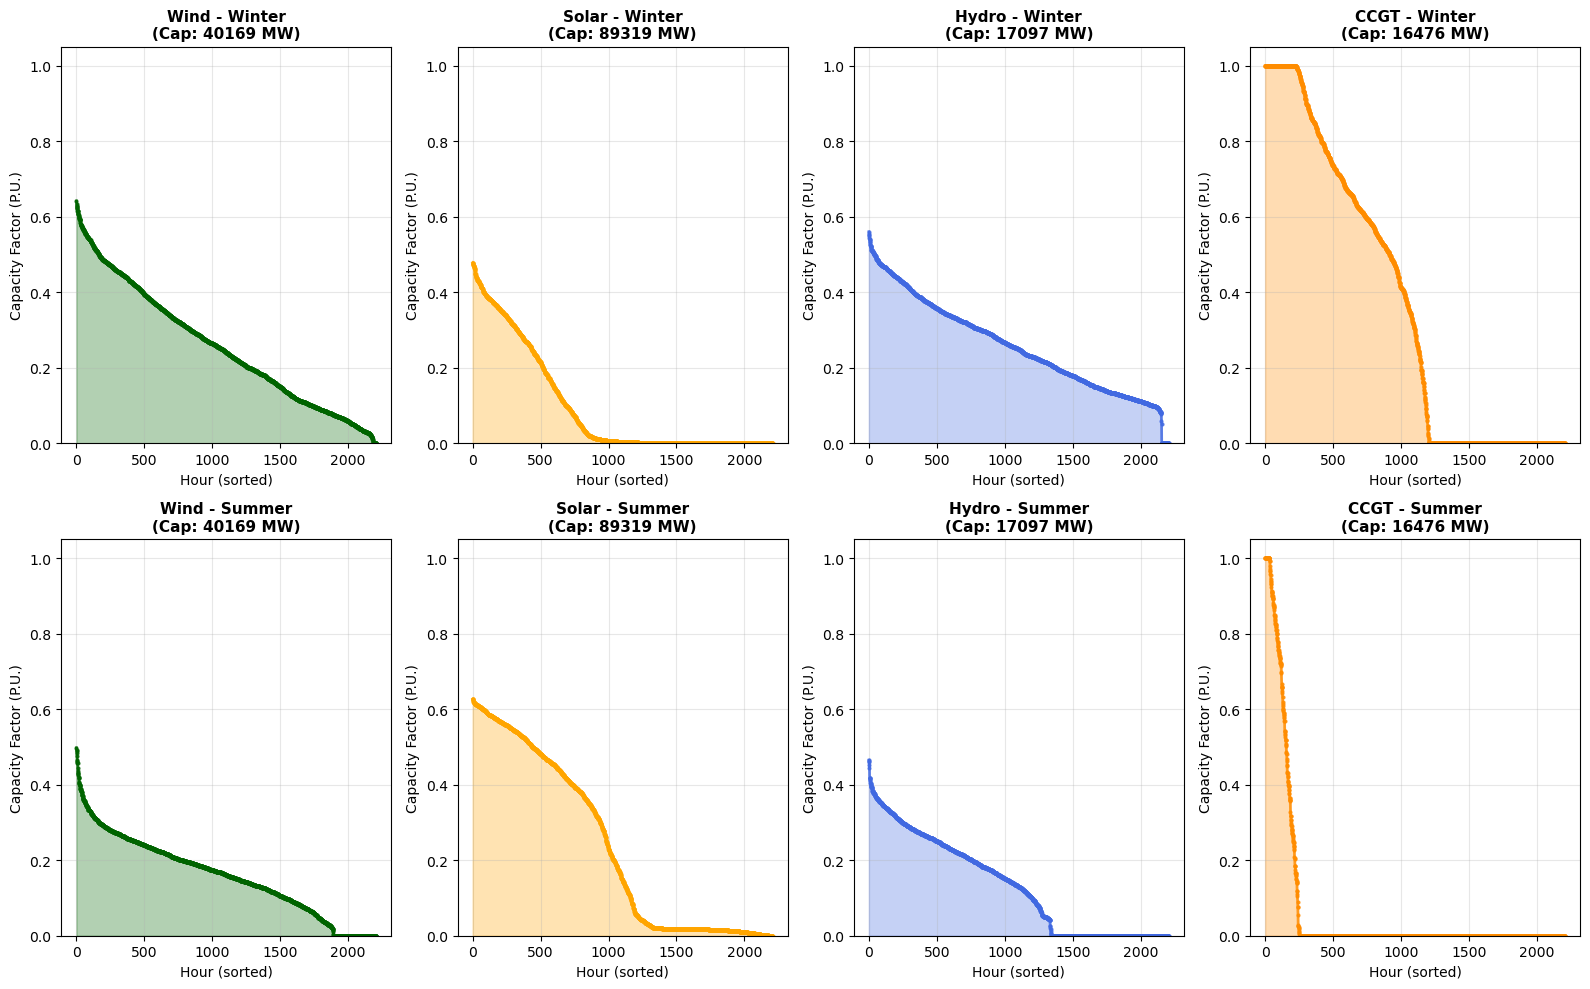


P.U. LOAD CURVE STATISTICS BY TECHNOLOGY (FULL SEASON)


WINTER SEASON:
------------------------------------------------------------------------------------------
Period: 2024-01-01 to 2025-01-01 (2208 hours)

Wind         | Avg P.U.: 0.255 | Peak P.U.: 0.641 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 40169 MW
Solar        | Avg P.U.: 0.094 | Peak P.U.: 0.478 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 89319 MW
Hydro        | Avg P.U.: 0.257 | Peak P.U.: 0.560 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 17097 MW
CCGT         | Avg P.U.: 0.367 | Peak P.U.: 1.000 | Min P.U.: 0.000 | Hours at full: 273 h | Cap: 16476 MW

SUMMER SEASON:
------------------------------------------------------------------------------------------
Period: 2024-06-01 to 2024-08-31 (2208 hours)

Wind         | Avg P.U.: 0.157 | Peak P.U.: 0.498 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 40169 MW
Solar        | Avg P.U.: 0.234 | Peak P.U.: 0.627 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 89319 MW
Hyd

In [43]:
# === Technology Load Curves - Per Unit (P.U.) Load Duration Curves ===
print("\n" + "="*70)
print("TECHNOLOGY LOAD DURATION CURVES - FULL SEASON (P.U. SORTED MAX TO MIN)")
print("="*70)

season_months = {'Winter': [12, 1, 2], 'Summer': [6, 7, 8]}
solution_df = result_with_storage.solution
color_map = {
    'Wind': 'darkgreen', 'Solar': 'orange', 'Hydro': 'royalblue',
    'Coal': 'darkred', 'Nuclear': 'purple', 'CCGT': 'darkorange'
}

# Exclude technologies with 0 capacity
techs_to_plot = [t for t in tech_params_opt.keys() if t in solution_df.columns and result_with_storage.optimal_capacities.get(t, 0) > 0]
n_techs = len(techs_to_plot)

# Create subplots: rows=seasons, cols=techs
fig, axes = plt.subplots(2, n_techs, figsize=(4*n_techs, 10))
if n_techs == 1:
    axes = axes.reshape(2, 1)

for season_idx, (season, months) in enumerate(season_months.items()):
    # Filter for entire season
    season_idx_bool = np.array(solution_df.index.month.isin(months))
    season_data = solution_df.iloc[season_idx_bool].copy()
    
    # Plot each technology individually in P.U.
    for tech_idx, tech in enumerate(techs_to_plot):
        ax = axes[season_idx, tech_idx]
        
        # Get capacity and normalize to P.U.
        capacity = result_with_storage.optimal_capacities.get(tech, 1)
        gen_pu = season_data[tech].values / capacity if capacity > 0 else season_data[tech].values
        
        # Sort P.U. values from max to min
        sorted_pu = np.sort(gen_pu)[::-1]
        
        # Plot technology generation in P.U.
        ax.plot(range(len(sorted_pu)), sorted_pu, 
                color=color_map.get(tech, 'gray'), linewidth=2, marker='o', markersize=2, alpha=0.8)
        ax.fill_between(range(len(sorted_pu)), sorted_pu, alpha=0.3, 
                        color=color_map.get(tech, 'gray'))
        
        # Set limits for P.U. to 0-1
        ax.set_ylim([0, 1.05])
        ax.set_title(f"{tech} - {season}\n(Cap: {capacity:.0f} MW)", 
                    fontsize=11, fontweight='bold')
        ax.set_ylabel('Capacity Factor (P.U.)', fontsize=10)
        ax.set_xlabel('Hour (sorted)', fontsize=10)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print P.U. load curve statistics
print("\n" + "="*70)
print("P.U. LOAD CURVE STATISTICS BY TECHNOLOGY (FULL SEASON)")
print("="*70 + "\n")

for season, months in season_months.items():
    print(f"\n{season.upper()} SEASON:")
    print("-" * 90)
    
    season_idx_bool = np.array(solution_df.index.month.isin(months))
    season_data = solution_df.iloc[season_idx_bool]
    
    print(f"Period: {season_data.index[0].strftime('%Y-%m-%d')} to {season_data.index[-1].strftime('%Y-%m-%d')} ({len(season_data)} hours)\n")
    
    for tech in techs_to_plot:
        if tech in season_data.columns:
            capacity = result_with_storage.optimal_capacities.get(tech, 1)
            gen_pu = season_data[tech].values / capacity if capacity > 0 else season_data[tech].values
            
            print(f"{tech:12s} | Avg P.U.: {gen_pu.mean():.3f} | Peak P.U.: {gen_pu.max():.3f} | "
                  f"Min P.U.: {gen_pu.min():.3f} | Hours at full: {(gen_pu >= 0.95).sum()} h | Cap: {capacity:.0f} MW")


ANNUAL ELECTRICITY MIX (WITH BATTERY & HYDROGEN STORAGE)

Total Annual Generation (including storage discharge): 285,490.3 GWh



,Technology,Generation (GWh),Share (%)
0,Solar,"125,552.6",44.0%
1,Wind,"73,981.5",25.9%
2,Hydro,"32,086.9",11.2%
3,Battery Discharge,"29,179.1",10.2%
4,CCGT,"24,690.2",8.6%


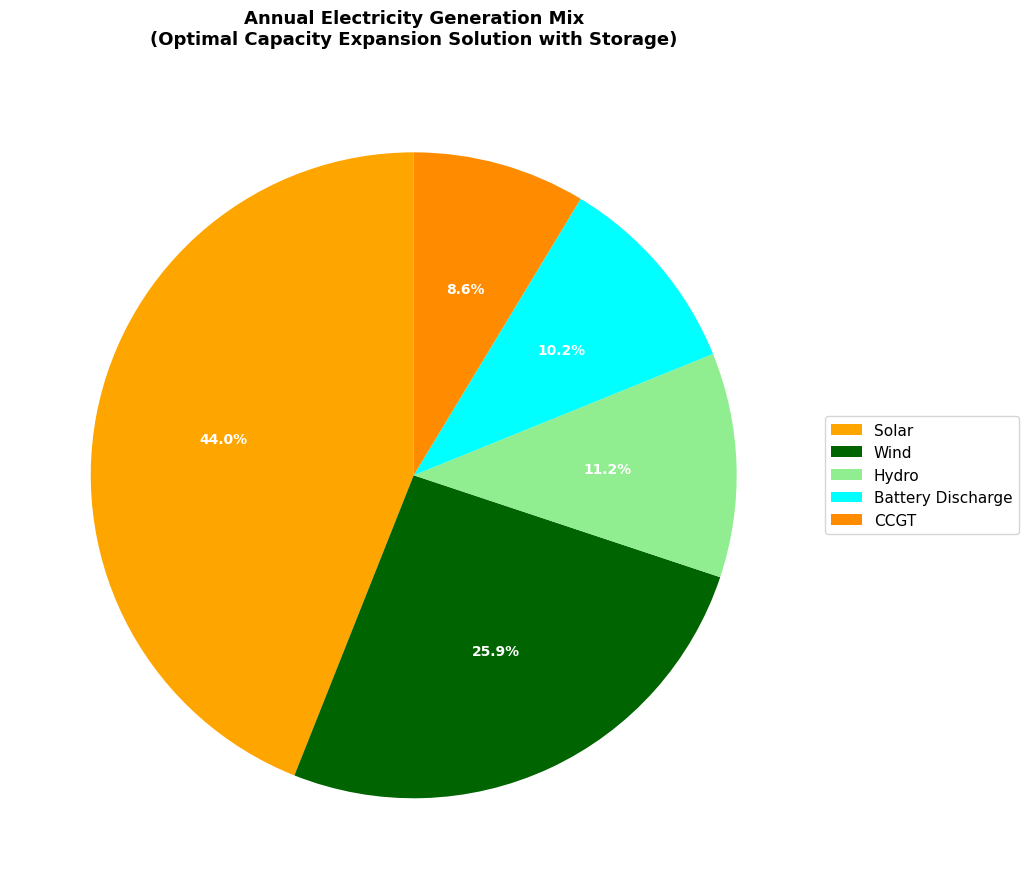

In [58]:
# === Annual Electricity Mix (WITH STORAGE) ===
print("\n" + "="*70)
print("ANNUAL ELECTRICITY MIX (WITH BATTERY & HYDROGEN STORAGE)")
print("="*70)

# Calculate total generation by technology for the entire year
annual_generation_storage = {}
for tech in techs_with_storage:
    if tech in solution_with_storage.columns:
        total_gen = solution_with_storage[tech].sum()
        annual_generation_storage[tech] = total_gen

# Add storage discharge energy
# Battery discharge (already positive in the dataframe)
if 'battery_discharge' in solution_with_storage.columns:
    battery_discharge_total = solution_with_storage['battery_discharge'].sum()
    annual_generation_storage['Battery Discharge'] = battery_discharge_total

# Hydrogen discharge (if available)
if 'hydrogen_discharge' in solution_with_storage.columns:
    hydrogen_discharge_total = solution_with_storage['hydrogen_discharge'].sum()
    annual_generation_storage['Hydrogen Discharge'] = hydrogen_discharge_total

# Filter out technologies with 0 generation
annual_generation_storage_nonzero = {tech: gen for tech, gen in annual_generation_storage.items() if gen > 0}

# Total generation (GWh)
total_gen_mwh_storage = sum(annual_generation_storage_nonzero.values())
total_gen_gwh_storage = total_gen_mwh_storage / 1000

# Create generation summary table (only non-zero)
gen_summary_storage = []
for tech in sorted(annual_generation_storage_nonzero.keys(), key=lambda t: annual_generation_storage_nonzero[t], reverse=True):
    gen_mwh = annual_generation_storage_nonzero[tech]
    gen_gwh = gen_mwh / 1000
    pct = (gen_mwh / total_gen_mwh_storage * 100) if total_gen_mwh_storage > 0 else 0
    
    gen_summary_storage.append({
        'Technology': tech,
        'Generation (GWh)': f"{gen_gwh:,.1f}",
        'Share (%)': f"{pct:.1f}%",
    })

print(f"\nTotal Annual Generation (including storage discharge): {total_gen_gwh_storage:,.1f} GWh\n")
gen_summary_storage_df = pd.DataFrame(gen_summary_storage)
display(gen_summary_storage_df)

# Plot pie chart of electricity mix (only non-zero generation)
fig, ax = plt.subplots(figsize=(12, 9))

# Sort by generation for better visualization
sorted_techs_storage = sorted(annual_generation_storage_nonzero.keys(), key=lambda t: annual_generation_storage_nonzero[t], reverse=True)
gen_values_storage = [annual_generation_storage_nonzero[tech] / 1000 for tech in sorted_techs_storage]  # Convert to GWh

# Define color map with updated colors for Battery and Hydro
color_map_updated = color_map.copy()
color_map_updated['Battery Discharge'] = 'cyan'
color_map_updated['Hydro'] = 'lightgreen'
colors_pie_storage = [color_map_updated.get(tech, 'gray') for tech in sorted_techs_storage]

# Create pie chart with better label positioning
wedges, texts, autotexts = ax.pie(gen_values_storage, labels=None, autopct='%1.1f%%',
                                     colors=colors_pie_storage, startangle=90, textprops={'fontsize': 10})

# Add legend with positioned labels to avoid overlap
ax.legend(sorted_techs_storage, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=11)

# Make percentage text bold and white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Annual Electricity Generation Mix\n(Optimal Capacity Expansion Solution with Storage)', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Mathematical Model: CO2-Constrained Capacity Expansion with Storage

The CO2-constrained capacity expansion problem minimizes total system cost while respecting maximum CO2 emissions:

### Decision Variables
- $p_g^{nom}$ = Installed capacity of technology $g$ [MW]
- $p_{g,t}$ = Generation of technology $g$ at time $t$ [MW]
- $b_{p,t}$ = Battery power dispatch (pos=discharge, neg=charge) at time $t$ [MW]
- $b_{e,t}$ = Battery energy level (state of charge) at time $t$ [MWh]
- $h_{p,t}$ = Hydrogen power dispatch at time $t$ [MW]
- $h_{e,t}$ = Hydrogen energy level at time $t$ [MWh]

### Objective Function
Minimize total annualized cost:
$$\text{min} \sum_g (C^{cap}_g \cdot p_g^{nom} + C^{FOM}_g \cdot p_g^{nom}) + \sum_g \sum_t (C^{var}_g \cdot p_{g,t}) + C^{bat}_{storage} + C^{H_2}_{storage}$$

Where:
- $C^{cap}_g$ = Annualized capital cost of technology $g$ [€/MW/year]
- $C^{FOM}_g$ = Fixed O&M cost [€/MW/year]
- $C^{var}_g$ = Variable cost [€/MWh]
- $C^{bat}_{storage}$, $C^{H_2}_{storage}$ = Storage capital costs

### Key Constraints

**Energy Balance (each hour $t$):**
$$\sum_g p_{g,t} + b_{p,t} + h_{p,t} = D_t$$

Where $D_t$ is demand at time $t$.

**Generation Limits:**
$$0 \leq p_{g,t} \leq p_g^{nom} \cdot A_{g,t}$$

Where $A_{g,t}$ is the availability profile (capacity factor) for renewables.

**Storage Energy Balance (Battery):**
$$b_{e,t} = b_{e,t-1} \cdot (1 - \sigma_{loss}) + b_{c,t} \cdot \eta_{charge}^{bat} - \frac{b_{d,t}}{\eta_{discharge}^{bat}}$$

**CO2 Emissions Cap:**
$$\sum_g \sum_t (p_{g,t} \cdot EF_g) \leq \text{CO2Cap}$$

Where $EF_g$ is the emission factor for technology $g$ [gCO2/MWh].

### Solution Method
Due to computational complexity of explicit CO2 constraint, we use an iterative **penalty method**:
1. Optimize without CO2 constraint (baseline)
2. If emissions exceed cap, increase marginal cost of high-emission technologies
3. Re-optimize with adjusted costs
4. Repeat until emissions are within the cap

In [45]:
# === CAPACITY EXPANSION WITH CO2 EMISSIONS CAP + STORAGE ===
print("\n" + "="*70)
print("CAPACITY EXPANSION WITH CO2 CAP CONSTRAINT + BATTERY + HYDROGEN STORAGE")
print("="*70)

# Reload module to get updated function WITH STORAGE
pycache_dir = module_dir / "__pycache__"
if pycache_dir.exists():
    shutil.rmtree(pycache_dir)

mods_to_remove = [mod for mod in sys.modules if 'Abstract_model' in mod]
for mod in mods_to_remove:
    del sys.modules[mod]

from python_codes.Abstract_model_temp import optimize_capacity_expansion_with_co2_cap

# ===== TUNABLE CO2 PARAMETERS =====
print("\n" + "-"*70)
print("TUNABLE PARAMETERS - CO2 EMISSIONS FACTORS & CAP")
print("-"*70)

# Emission factors (gCO2/MWh) - Lifecycle assessment + IPCC values
emission_factors = {
    'Wind': 11,           # Wind onshore: ~11 gCO2/MWh
    'Solar': 48,          # Solar PV: ~48 gCO2/MWh
    'Hydro': 24,          # Hydroelectric: ~24 gCO2/MWh
    'CCGT': 490,          # Natural gas CCGT: ~490 gCO2/MWh
    'Coal': 820,          # Coal: ~820 gCO2/MWh
    'Nuclear': 12,        # Nuclear: ~12 gCO2/MWh
}

print("\nEmission Factors (gCO2/MWh):")
for tech, factor in emission_factors.items():
    print(f"  {tech:12s}: {factor:6.0f} gCO2/MWh")

# CO2 Emissions Cap - TUNE THIS VALUE to see how capacity mix changes
# The cap is in grams of CO2 (1 million tonnes CO2 = 1e15 gCO2)
emission_cap_mtonnes = 15  # Million tonnes CO2/year (TUNABLE - try 10, 15, 20, 50, etc.)
emission_cap_gco2 = emission_cap_mtonnes * 1e9

print(f"\nCO2 Emissions Cap (TUNABLE):")
print(f"  {emission_cap_mtonnes:.1f} Million tonnes CO2/year")
print(f"  = {emission_cap_gco2:.2e} gCO2/year")

# Calculate unconstrained baseline emissions for reference
unconstrained_emissions = 0.0
for tech in tech_params_opt.keys():
    if tech in result.solution.columns:
        total_gen = result.solution[tech].sum()
        emission_factor = emission_factors.get(tech, 0.0)
        unconstrained_emissions += total_gen * emission_factor

print(f"\nReference (unconstrained solution): {unconstrained_emissions/1e9:.2f} Mt CO2/year")
reduction_needed_pct = max(0, (unconstrained_emissions - emission_cap_gco2) / unconstrained_emissions * 100) if unconstrained_emissions > 0 else 0
print(f"Reduction needed: {reduction_needed_pct:.1f}%\n")

# ===== STORAGE PARAMETERS (from CSV) =====
print("-"*70)
print("STORAGE PARAMETERS (Battery & Hydrogen)")
print("-"*70)

# Use the costs already loaded from CSV earlier
battery_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Battery system'].iloc[0]
battery_overnight_cost = battery_tech_row['Overnight Cost']
battery_fom = battery_tech_row['FOM (%/a)'] / 100.0
battery_efficiency = battery_tech_row['Efficiency']
battery_fixed_cost_co2 = battery_overnight_cost * 1000 * battery_fom

hydrogen_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Hydrogen system'].iloc[0]
hydrogen_overnight_cost = hydrogen_tech_row['Overnight Cost']
hydrogen_fom = hydrogen_tech_row['FOM (%/a)'] / 100.0
hydrogen_efficiency = hydrogen_tech_row['Efficiency']
hydrogen_fixed_cost_co2 = hydrogen_overnight_cost * 1000 * hydrogen_fom

print(f"Battery:   €{battery_fixed_cost_co2:.0f}/MW/year, {battery_efficiency*100:.0f}% round-trip efficiency")
print(f"Hydrogen:  €{hydrogen_fixed_cost_co2:.0f}/MW/year, {hydrogen_efficiency*100:.0f}% round-trip efficiency\n")

# === Run capacity expansion WITH CO2 CAP and STORAGE ===
print("="*70)
print("RUNNING OPTIMIZATION WITH CO2 CAP CONSTRAINT + STORAGE...")
print("="*70 + "\n")

data_co2 = CapacityExpansionInput(
    hourly_demand=demand_yearly,
    tech_params=tech_params_opt,
    renewable_profiles=renewable_profiles,
)

result_co2 = optimize_capacity_expansion_with_co2_cap(
    data=data_co2,
    emission_factors=emission_factors,
    emission_cap=emission_cap_gco2,
    # Battery parameters
    battery_max_hours=4.0,
    battery_charging_efficiency=battery_efficiency**0.5,
    battery_discharging_efficiency=battery_efficiency**0.5,
    battery_fixed_cost=battery_fixed_cost_co2,
    battery_max_capacity_limit=50000.0,
    # Hydrogen parameters
    hydrogen_max_hours=168.0,
    hydrogen_charging_efficiency=hydrogen_efficiency**0.5,
    hydrogen_discharging_efficiency=hydrogen_efficiency**0.5,
    hydrogen_fixed_cost=hydrogen_fixed_cost_co2,
    hydrogen_max_capacity_limit=50000.0,
    solver_name="gurobi",
)

print(f"Status: {result_co2.status}")
print(f"Total annual cost: €{result_co2.objective_value:,.0f}\n")

# === Results: Capacity Table WITH CO2 CAP ===
print("="*70)
print("OPTIMAL CAPACITIES (WITH CO2 CAP + STORAGE)")
print("="*70)

capacity_table_co2 = pd.DataFrame({
    'Technology': list(tech_params_opt.keys()) + ['Battery', 'Hydrogen'],
    'Capacity (MW)': [result_co2.optimal_capacities.get(tech, 0) for tech in tech_params_opt.keys()] + 
                     [result_co2.optimal_capacities.get('battery_power', 0), result_co2.optimal_capacities.get('hydrogen_power', 0)],
    'Previous (MW)': [result.optimal_capacities.get(tech, 0) for tech in tech_params_opt.keys()] +
                     [result_with_storage.optimal_capacities.get('battery_power', 0), result_with_storage.optimal_capacities.get('hydrogen_power', 0)],
})

capacity_table_co2['Change (MW)'] = capacity_table_co2['Capacity (MW)'] - capacity_table_co2['Previous (MW)']
capacity_table_co2 = capacity_table_co2.sort_values('Capacity (MW)', ascending=False)

print("\nCapacity Comparison (Unconstrained vs CO2 Cap):\n")
display(capacity_table_co2.round(0))

# Storage energy capacities
print(f"\nStorage Energy Capacities:")
print(f"  Battery:   {result_co2.optimal_capacities.get('battery_energy', 0):,.0f} MWh (4-hour duration)")
print(f"  Hydrogen:  {result_co2.optimal_capacities.get('hydrogen_energy', 0):,.0f} MWh (1-week duration)\n")

# === Cost breakdown WITH CO2 CAP ===
print("="*70)
print("COST BREAKDOWN (WITH CO2 CAP + STORAGE)")
print("="*70)

cost_summary_co2 = []
for tech, costs in result_co2.technology_costs.items():
    cost_summary_co2.append({
        'Technology': tech,
        'Fixed Cost (€M)': f"{costs['fixed_cost']/1e6:,.1f}",
        'Variable Cost (€M)': f"{costs['variable_cost']/1e6:,.1f}",
        'Total (€M)': f"{costs['total']/1e6:,.1f}",
    })

cost_summary_co2_df = pd.DataFrame(cost_summary_co2).sort_values('Technology')
print()
display(cost_summary_co2_df)

# === KEY FINDINGS ===
print("\n" + "="*70)
print("KEY FINDINGS: HOW CO2 CAP CHANGES THE CAPACITY MIX")
print("="*70 + "\n")

# Calculate emissions change
co2_emissions_now = 0.0
for tech in tech_params_opt.keys():
    if tech in result_co2.solution.columns:
        total_gen = result_co2.solution[tech].sum()
        emission_factor = emission_factors.get(tech, 0.0)
        co2_emissions_now += total_gen * emission_factor

print(f"Emissions:")
print(f"  Unconstrained: {unconstrained_emissions/1e9:>7.2f} Mt CO2/year")
print(f"  CO2 Cap:       {emission_cap_mtonnes:>7.1f} Mt CO2/year (target)")
print(f"  Actual Result: {co2_emissions_now/1e9:>7.2f} Mt CO2/year")
print(f"  Reduction:     {(unconstrained_emissions - co2_emissions_now)/1e9:>7.2f} Mt CO2/year\n")

# Technology changes
print("Capacity Changes (Renewables & Storage):")
for tech in ['Wind', 'Solar', 'Battery', 'Hydrogen']:
    unconstrained_cap = result.optimal_capacities.get(tech, 0) if tech != 'Battery' and tech != 'Hydrogen' else (result_with_storage.optimal_capacities.get(tech + '_power', 0) if tech in ['Battery', 'Hydrogen'] else result_with_storage.optimal_capacities.get(tech, 0))
    co2_cap_cap = result_co2.optimal_capacities.get(tech, 0) if tech != 'Battery' and tech != 'Hydrogen' else result_co2.optimal_capacities.get(tech + '_power', 0)
    change = co2_cap_cap - unconstrained_cap
    pct_change = (change / unconstrained_cap * 100) if unconstrained_cap > 0 else (100 if co2_cap_cap > 0 else 0)
    symbol = "↑" if change > 0 else ("↓" if change < 0 else "—")
    print(f"  {tech:10s}: {unconstrained_cap:>7.0f} MW → {co2_cap_cap:>7.0f} MW ({symbol} {abs(pct_change):>6.1f}%)")

print("\nFossil Fuels Reduced:")
for tech in ['Coal', 'CCGT']:
    unconstrained_cap = result.optimal_capacities.get(tech, 0)
    co2_cap_cap = result_co2.optimal_capacities.get(tech, 0)
    change = co2_cap_cap - unconstrained_cap
    pct_change = (change / unconstrained_cap * 100) if unconstrained_cap > 0 else (100 if co2_cap_cap > 0 else 0)
    symbol = "↑" if change > 0 else ("↓" if change < 0 else "—")
    print(f"  {tech:10s}: {unconstrained_cap:>7.0f} MW → {co2_cap_cap:>7.0f} MW ({symbol} {abs(pct_change):>6.1f}%)")


CAPACITY EXPANSION WITH CO2 CAP CONSTRAINT + BATTERY + HYDROGEN STORAGE

----------------------------------------------------------------------
TUNABLE PARAMETERS - CO2 EMISSIONS FACTORS & CAP
----------------------------------------------------------------------

Emission Factors (gCO2/MWh):
  Wind        :     11 gCO2/MWh
  Solar       :     48 gCO2/MWh
  Hydro       :     24 gCO2/MWh
  CCGT        :    490 gCO2/MWh
  Coal        :    820 gCO2/MWh
  Nuclear     :     12 gCO2/MWh

CO2 Emissions Cap (TUNABLE):
  15.0 Million tonnes CO2/year
  = 1.50e+10 gCO2/year

Reference (unconstrained solution): 26.59 Mt CO2/year
Reduction needed: 43.6%

----------------------------------------------------------------------
STORAGE PARAMETERS (Battery & Hydrogen)
----------------------------------------------------------------------
Battery:   €9000/MW/year, 90% round-trip efficiency
Hydrogen:  €84000/MW/year, 35% round-trip efficiency

RUNNING OPTIMIZATION WITH CO2 CAP CONSTRAINT + STORAGE...


C

d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment\python_codes\Abstract_model_temp.py:987: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name=solver_name, multi_investment_periods=multi_investment_periods, log_to_console=False)
Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 152.13it/s]
INFO:linopy.io: Writing time: 0.36s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2663265


...

  ⚠ PyPSA post-processing warning (solve succeeded): ValueError
    setting an array element with a sequence....

  Extracting results:
    Technologies: [('Wind', '29993 MW'), ('Solar', '87563 MW'), ('Hydro', '17097 MW'), ('CCGT', '3791 MW'), ('Coal', '0 MW'), ('Nuclear', '11037 MW')]
    Battery: 29806 MW / 119223 MWh
    Hydrogen: 2599 MW / 436548 MWh

Emissions Summary:
  Total emissions: 8.19 Mt CO2/year
  CO2 cap: 15.00 Mt CO2/year
  Status: ✓ MEETS CAP

Status: optimal
Total annual cost: €5,457,954,347

OPTIMAL CAPACITIES (WITH CO2 CAP + STORAGE)

Capacity Comparison (Unconstrained vs CO2 Cap):



,Technology,Capacity (MW),Previous (MW),Change (MW)
1,Solar,87563.0,52592.0,34972.0
0,Wind,29993.0,53970.0,-23976.0
6,Battery,29806.0,31180.0,-1374.0
2,Hydro,17097.0,17097.0,0.0
5,Nuclear,11037.0,0.0,11037.0
3,CCGT,3791.0,25280.0,-21489.0
7,Hydrogen,2599.0,0.0,2599.0
4,Coal,0.0,0.0,0.0



Storage Energy Capacities:
  Battery:   119,223 MWh (4-hour duration)
  Hydrogen:  436,548 MWh (1-week duration)

COST BREAKDOWN (WITH CO2 CAP + STORAGE)



,Technology,Fixed Cost (€M),Variable Cost (€M),Total (€M)
3,CCGT,60.7,19.0,79.6
4,Coal,0.0,0.0,0.0
2,Hydro,341.9,0.0,341.9
5,Nuclear,"1,655.5",334.7,"1,990.2"
1,Solar,"1,269.7",0.0,"1,269.7"
0,Wind,"1,063.6",0.0,"1,063.6"
6,battery,268.3,0.0,268.3
7,hydrogen,218.3,0.0,218.3



KEY FINDINGS: HOW CO2 CAP CHANGES THE CAPACITY MIX

Emissions:
  Unconstrained:   26.59 Mt CO2/year
  CO2 Cap:          15.0 Mt CO2/year (target)
  Actual Result:    8.19 Mt CO2/year
  Reduction:       18.40 Mt CO2/year

Capacity Changes (Renewables & Storage):
  Wind      :   53970 MW →   29993 MW (↓   44.4%)
  Solar     :   52592 MW →   87563 MW (↑   66.5%)
  Battery   :       0 MW →       0 MW (—    0.0%)
  Hydrogen  :       0 MW →       0 MW (—    0.0%)

Fossil Fuels Reduced:
  Coal      :       0 MW →       0 MW (—    0.0%)
  CCGT      :   25280 MW →    3791 MW (↓   85.0%)



VISUALIZATION: CAPACITY COMPARISON - EFFECT OF CO2 CAP



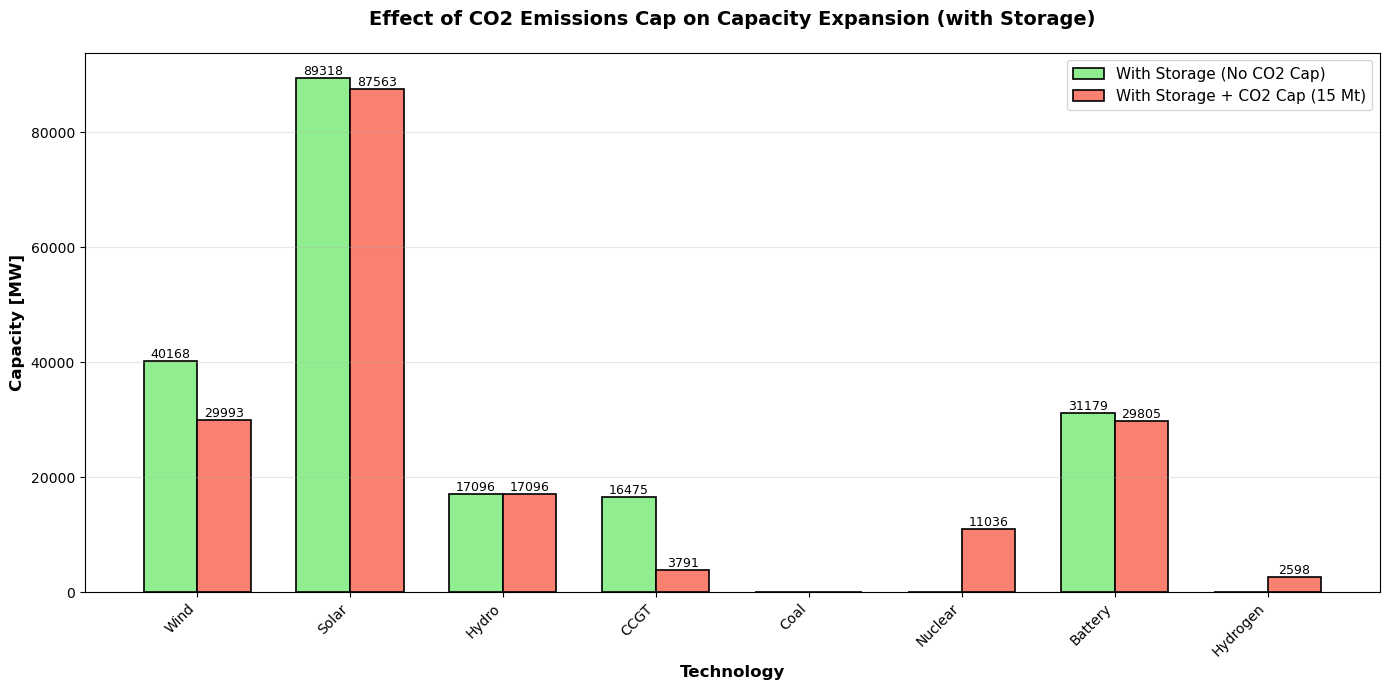

✓ Capacity comparison chart displayed



In [46]:
# === VISUALIZATION: Capacity Comparison (Storage + CO2 Cap vs Storage only) ===
print("\n" + "="*70)
print("VISUALIZATION: CAPACITY COMPARISON - EFFECT OF CO2 CAP")
print("="*70 + "\n")

# Prepare data for comparison visualization
comparison_techs = [t for t in tech_params_opt.keys() if t in solution_df.columns]
storage_caps = [result_with_storage.optimal_capacities.get(t, 0) for t in comparison_techs]
co2_caps = [result_co2.optimal_capacities.get(t, 0) for t in comparison_techs]

# Add battery and hydrogen
comparison_techs_extended = comparison_techs + ['Battery', 'Hydrogen']
storage_caps_ext = storage_caps + [result_with_storage.optimal_capacities.get('battery_power', 0), 
                                    result_with_storage.optimal_capacities.get('hydrogen_power', 0)]
co2_caps_ext = co2_caps + [result_co2.optimal_capacities.get('battery_power', 0), 
                            result_co2.optimal_capacities.get('hydrogen_power', 0)]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(comparison_techs_extended))
width = 0.35

bars1 = ax.bar(x - width/2, storage_caps_ext, width, label='With Storage (No CO2 Cap)', color='lightgreen', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, co2_caps_ext, width, label=f'With Storage + CO2 Cap ({emission_cap_mtonnes} Mt)', color='salmon', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Technology', fontsize=12, fontweight='bold')
ax.set_ylabel('Capacity [MW]', fontsize=12, fontweight='bold')
ax.set_title('Effect of CO2 Emissions Cap on Capacity Expansion (with Storage)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_techs_extended, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Capacity comparison chart displayed\n")


ANNUAL ELECTRICITY MIX (WITH CO2 CAP + STORAGE)

Total Annual Generation: 285,908.6 GWh



,Technology,Generation (GWh),Share (%)
0,Solar,"123,785.8",43.3%
1,Wind,"57,073.3",20.0%
2,Nuclear,"39,377.0",13.8%
3,Hydro,"35,135.2",12.3%
4,Battery Discharge,"28,365.9",9.9%
5,Hydrogen Discharge,"1,539.5",0.5%
6,CCGT,631.8,0.2%


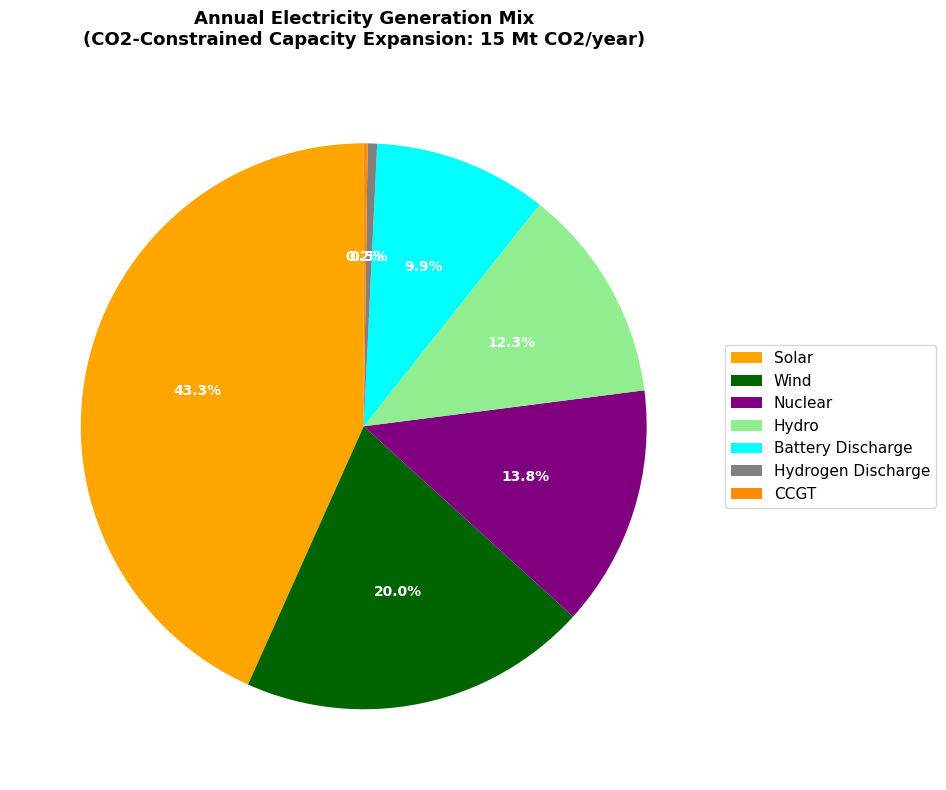


✓ Electricity mix chart displayed



In [60]:
# === Annual Electricity Mix (WITH CO2 CAP) ===
print("\n" + "="*70)
print("ANNUAL ELECTRICITY MIX (WITH CO2 CAP + STORAGE)")
print("="*70)

# Calculate total generation by technology for the entire year (CO2-constrained)
annual_generation_co2 = {}
techs_co2 = [t for t in tech_params_opt.keys() if t in result_co2.solution.columns]

for tech in techs_co2:
    total_gen = result_co2.solution[tech].sum()
    annual_generation_co2[tech] = total_gen

# Add storage discharge energy
if 'battery_discharge' in result_co2.solution.columns:
    battery_discharge_total = result_co2.solution['battery_discharge'].sum()
    annual_generation_co2['Battery Discharge'] = battery_discharge_total

if 'hydrogen_discharge' in result_co2.solution.columns:
    hydrogen_discharge_total = result_co2.solution['hydrogen_discharge'].sum()
    annual_generation_co2['Hydrogen Discharge'] = hydrogen_discharge_total

# Filter out technologies with 0 generation
annual_generation_co2_nonzero = {tech: gen for tech, gen in annual_generation_co2.items() if gen > 0}

# Total generation (GWh)
total_gen_mwh_co2 = sum(annual_generation_co2_nonzero.values())
total_gen_gwh_co2 = total_gen_mwh_co2 / 1000

# Create generation summary table (only non-zero)
gen_summary_co2 = []
for tech in sorted(annual_generation_co2_nonzero.keys(), key=lambda t: annual_generation_co2_nonzero[t], reverse=True):
    gen_mwh = annual_generation_co2_nonzero[tech]
    gen_gwh = gen_mwh / 1000
    pct = (gen_mwh / total_gen_mwh_co2 * 100) if total_gen_mwh_co2 > 0 else 0
    
    gen_summary_co2.append({
        'Technology': tech,
        'Generation (GWh)': f"{gen_gwh:,.1f}",
        'Share (%)': f"{pct:.1f}%",
    })

print(f"\nTotal Annual Generation: {total_gen_gwh_co2:,.1f} GWh\n")
gen_summary_co2_df = pd.DataFrame(gen_summary_co2)
display(gen_summary_co2_df)

# Plot pie chart of electricity mix (only non-zero generation)
fig, ax = plt.subplots(figsize=(10, 8))

# Sort by generation for better visualization
sorted_techs_co2 = sorted(annual_generation_co2_nonzero.keys(), key=lambda t: annual_generation_co2_nonzero[t], reverse=True)
gen_values_co2 = [annual_generation_co2_nonzero[tech] / 1000 for tech in sorted_techs_co2]  # Convert to GWh

# Define color map with updated colors for Battery and Hydro
color_map_co2 = color_map.copy()
color_map_co2['Battery Discharge'] = 'cyan'
color_map_co2['Hydro'] = 'lightgreen'
colors_pie_co2 = [color_map_co2.get(tech, 'gray') for tech in sorted_techs_co2]

# Create pie chart with better label positioning
wedges, texts, autotexts = ax.pie(gen_values_co2, labels=None, autopct='%1.1f%%',
                                     colors=colors_pie_co2, startangle=90, textprops={'fontsize': 10})

# Add legend with positioned labels to avoid overlap
ax.legend(sorted_techs_co2, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=11)

# Make percentage text bold and white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title(f'Annual Electricity Generation Mix\n(CO2-Constrained Capacity Expansion: {emission_cap_mtonnes} Mt CO2/year)', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ Electricity mix chart displayed\n")


TECHNOLOGY LOAD DURATION CURVES (CO2-CONSTRAINED) - FULL SEASON (P.U. SORTED MAX TO MIN)


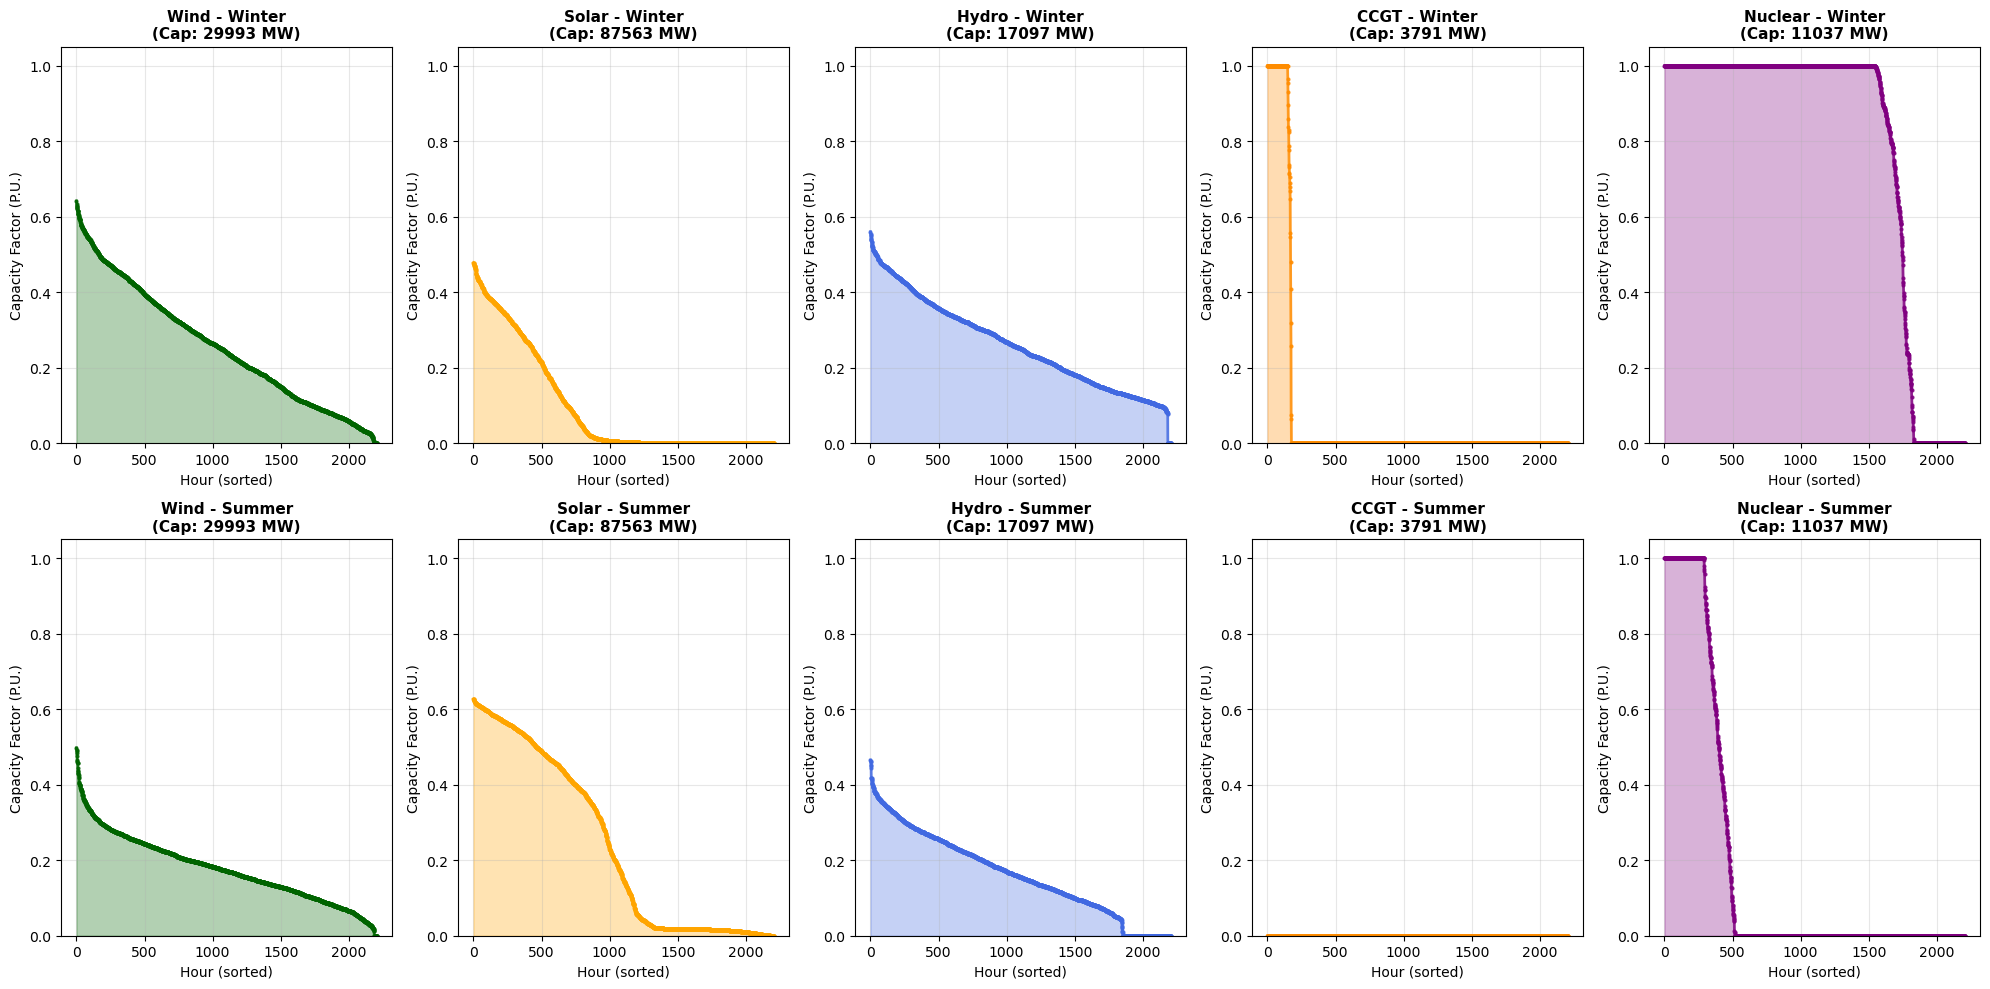


P.U. LOAD CURVE STATISTICS BY TECHNOLOGY (WITH CO2 CAP)


WINTER SEASON:
------------------------------------------------------------------------------------------
Period: 2024-01-01 to 2025-01-01 (2208 hours)

Wind         | Avg P.U.: 0.255 | Peak P.U.: 0.641 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 29993 MW
Solar        | Avg P.U.: 0.094 | Peak P.U.: 0.478 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 87563 MW
Hydro        | Avg P.U.: 0.260 | Peak P.U.: 0.560 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 17097 MW
CCGT         | Avg P.U.: 0.075 | Peak P.U.: 1.000 | Min P.U.: 0.000 | Hours at full: 151 h | Cap: 3791 MW
Nuclear      | Avg P.U.: 0.783 | Peak P.U.: 1.000 | Min P.U.: 0.000 | Hours at full: 1585 h | Cap: 11037 MW

SUMMER SEASON:
------------------------------------------------------------------------------------------
Period: 2024-06-01 to 2024-08-31 (2208 hours)

Wind         | Avg P.U.: 0.176 | Peak P.U.: 0.498 | Min P.U.: 0.000 | Hours at full: 0 h | Cap: 29993 MW


In [48]:
# === Technology Load Curves (CO2-Constrained) - Per Unit (P.U.) Load Duration Curves ===
print("\n" + "="*70)
print("TECHNOLOGY LOAD DURATION CURVES (CO2-CONSTRAINED) - FULL SEASON (P.U. SORTED MAX TO MIN)")
print("="*70)

solution_co2_df = result_co2.solution
season_months = {'Winter': [12, 1, 2], 'Summer': [6, 7, 8]}

# Exclude technologies with 0 capacity
techs_co2_plot = [t for t in tech_params_opt.keys() if t in solution_co2_df.columns and result_co2.optimal_capacities.get(t, 0) > 0]
n_techs_co2 = len(techs_co2_plot)

# Create subplots: rows=seasons, cols=techs
fig, axes = plt.subplots(2, n_techs_co2, figsize=(4*n_techs_co2, 10))
if n_techs_co2 == 1:
    axes = axes.reshape(2, 1)

for season_idx, (season, months) in enumerate(season_months.items()):
    # Filter for entire season
    season_idx_bool = np.array(solution_co2_df.index.month.isin(months))
    season_data = solution_co2_df.iloc[season_idx_bool].copy()
    
    # Plot each technology individually in P.U.
    for tech_idx, tech in enumerate(techs_co2_plot):
        ax = axes[season_idx, tech_idx]
        
        # Get capacity and normalize to P.U.
        capacity = result_co2.optimal_capacities.get(tech, 1)
        gen_pu = season_data[tech].values / capacity if capacity > 0 else season_data[tech].values
        
        # Sort P.U. values from max to min
        sorted_pu = np.sort(gen_pu)[::-1]
        
        # Plot technology generation in P.U.
        ax.plot(range(len(sorted_pu)), sorted_pu, 
                color=color_map.get(tech, 'gray'), linewidth=2, marker='o', markersize=2, alpha=0.8)
        ax.fill_between(range(len(sorted_pu)), sorted_pu, alpha=0.3, 
                        color=color_map.get(tech, 'gray'))
        
        # Set limits for P.U. to 0-1
        ax.set_ylim([0, 1.05])
        ax.set_title(f"{tech} - {season}\n(Cap: {capacity:.0f} MW)", 
                    fontsize=11, fontweight='bold')
        ax.set_ylabel('Capacity Factor (P.U.)', fontsize=10)
        ax.set_xlabel('Hour (sorted)', fontsize=10)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print P.U. load curve statistics
print("\n" + "="*70)
print("P.U. LOAD CURVE STATISTICS BY TECHNOLOGY (WITH CO2 CAP)")
print("="*70 + "\n")

for season, months in season_months.items():
    print(f"\n{season.upper()} SEASON:")
    print("-" * 90)
    
    season_idx_bool = np.array(solution_co2_df.index.month.isin(months))
    season_data = solution_co2_df.iloc[season_idx_bool]
    
    print(f"Period: {season_data.index[0].strftime('%Y-%m-%d')} to {season_data.index[-1].strftime('%Y-%m-%d')} ({len(season_data)} hours)\n")
    
    for tech in techs_co2_plot:
        if tech in season_data.columns:
            capacity = result_co2.optimal_capacities.get(tech, 1)
            gen_pu = season_data[tech].values / capacity if capacity > 0 else season_data[tech].values
            
            print(f"{tech:12s} | Avg P.U.: {gen_pu.mean():.3f} | Peak P.U.: {gen_pu.max():.3f} | "
                  f"Min P.U.: {gen_pu.min():.3f} | Hours at full: {(gen_pu >= 0.95).sum()} h | Cap: {capacity:.0f} MW")

print("\n✓ Load duration curves displayed\n")


COST BREAKDOWN ANALYSIS (CO2-CONSTRAINED SOLUTION)



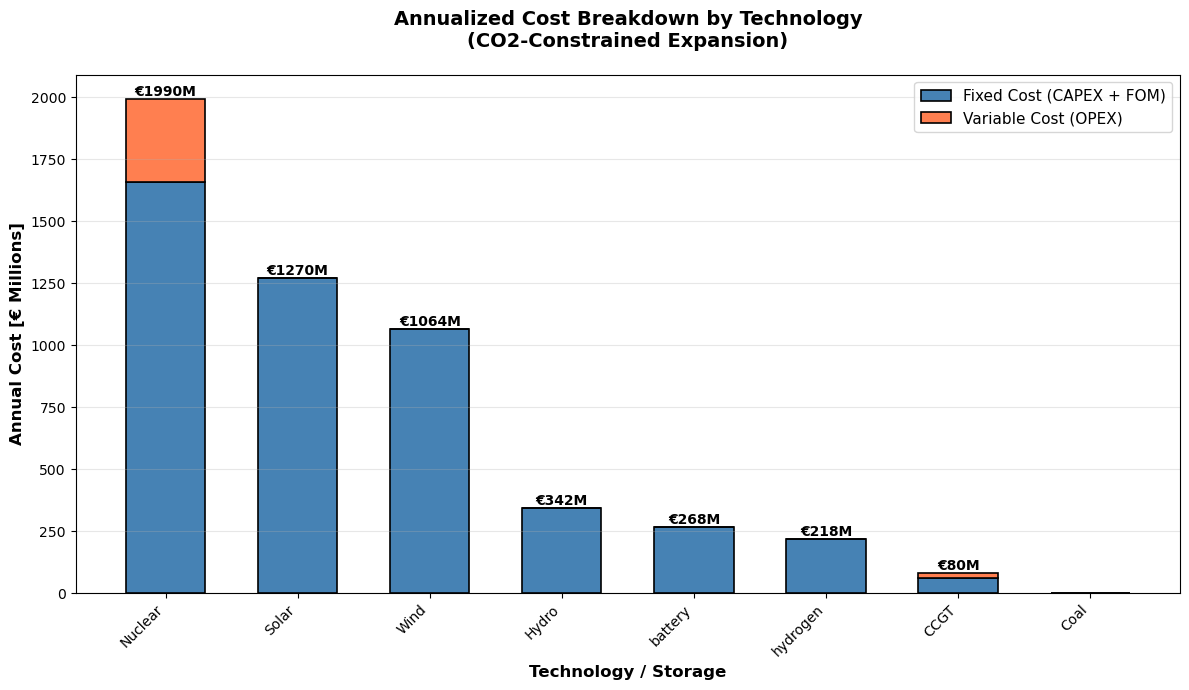


Detailed Cost Breakdown:



,Technology,Fixed Cost (€M),Variable Cost (€M),Total Cost (€M)
0,Wind,"1,063.6",0.0,"1,063.6"
1,Solar,"1,269.7",0.0,"1,269.7"
2,Hydro,341.9,0.0,341.9
3,CCGT,60.7,19.0,79.6
4,Coal,0.0,0.0,0.0
5,Nuclear,"1,655.5",334.7,"1,990.2"
6,battery,268.3,0.0,268.3
7,hydrogen,218.3,0.0,218.3



TOTAL SYSTEM COST SUMMARY (CO2-CONSTRAINED)
Total Fixed Cost (CAPEX + FOM):    €     4,877.9 Million
Total Variable Cost (OPEX):        €       353.7 Million
Total System Cost:                 €     5,231.5 Million

Cost per unit of electricity:       €       20.44 /MWh

✓ Cost breakdown visualization complete



In [49]:
# === Cost Breakdown Visualization (CO2-Constrained) ===
print("\n" + "="*70)
print("COST BREAKDOWN ANALYSIS (CO2-CONSTRAINED SOLUTION)")
print("="*70 + "\n")

# Extract cost data for visualization
cost_techs = list(result_co2.technology_costs.keys())
fixed_costs = [result_co2.technology_costs[tech]['fixed_cost'] / 1e6 for tech in cost_techs]
variable_costs = [result_co2.technology_costs[tech]['variable_cost'] / 1e6 for tech in cost_techs]

# Sort by total cost
cost_data_co2 = [(t, result_co2.technology_costs[t]['fixed_cost']/1e6, result_co2.technology_costs[t]['variable_cost']/1e6) 
                  for t in cost_techs]
cost_data_co2_sorted = sorted(cost_data_co2, key=lambda x: x[1] + x[2], reverse=True)

techs_sorted = [t[0] for t in cost_data_co2_sorted]
fixed_sorted = [t[1] for t in cost_data_co2_sorted]
variable_sorted = [t[2] for t in cost_data_co2_sorted]

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(techs_sorted))
width = 0.6

bars1 = ax.bar(x, fixed_sorted, width, label='Fixed Cost (CAPEX + FOM)', 
               color='steelblue', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x, variable_sorted, width, bottom=fixed_sorted, label='Variable Cost (OPEX)', 
               color='coral', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Technology / Storage', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Cost [€ Millions]', fontsize=12, fontweight='bold')
ax.set_title('Annualized Cost Breakdown by Technology\n(CO2-Constrained Expansion)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(techs_sorted, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)

# Add total cost labels on top of bars
for i, (f, v) in enumerate(zip(fixed_sorted, variable_sorted)):
    total = f + v
    if total > 0:
        ax.text(i, total, f'€{total:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed cost table
print("\nDetailed Cost Breakdown:\n")
cost_table_co2 = []
total_fixed_co2 = 0
total_variable_co2 = 0

for tech in cost_techs:
    costs = result_co2.technology_costs[tech]
    fixed = costs['fixed_cost'] / 1e6
    variable = costs['variable_cost'] / 1e6
    total = costs['total'] / 1e6
    
    total_fixed_co2 += fixed
    total_variable_co2 += variable
    
    cost_table_co2.append({
        'Technology': tech,
        'Fixed Cost (€M)': f"{fixed:,.1f}",
        'Variable Cost (€M)': f"{variable:,.1f}",
        'Total Cost (€M)': f"{total:,.1f}",
    })

cost_table_co2_df = pd.DataFrame(cost_table_co2)
display(cost_table_co2_df)

print(f"\n{'='*70}")
print(f"TOTAL SYSTEM COST SUMMARY (CO2-CONSTRAINED)")
print(f"{'='*70}")
print(f"Total Fixed Cost (CAPEX + FOM):    €{total_fixed_co2:>12,.1f} Million")
print(f"Total Variable Cost (OPEX):        €{total_variable_co2:>12,.1f} Million")
print(f"Total System Cost:                 €{total_fixed_co2 + total_variable_co2:>12,.1f} Million")
print(f"\nCost per unit of electricity:       €{(total_fixed_co2 + total_variable_co2) * 1e6 / total_gen_mwh_co2:>12,.2f} /MWh")
print(f"{'='*70}\n")

print("✓ Cost breakdown visualization complete\n")


COMPARATIVE ANALYSIS: THREE OPTIMIZATION SCENARIOS


COMPARATIVE ANALYSIS: EFFECT OF CO2 CAP ON STORAGE SOLUTION


SCENARIO COMPARISON TABLE:



,Scenario,Total Cost (€M),Wind (MW),Solar (MW),Coal (MW),CCGT (MW),Battery (MW),Hydrogen (MW),Emissions (Mt CO2)
0,With Storage (No CO2 Cap),"4,346.4",40169,89319,0,16476,31180,0,19.71
1,With Storage + CO2 Cap (15 Mt),"5,458.0",29993,87563,0,3791,29806,2599,8.19


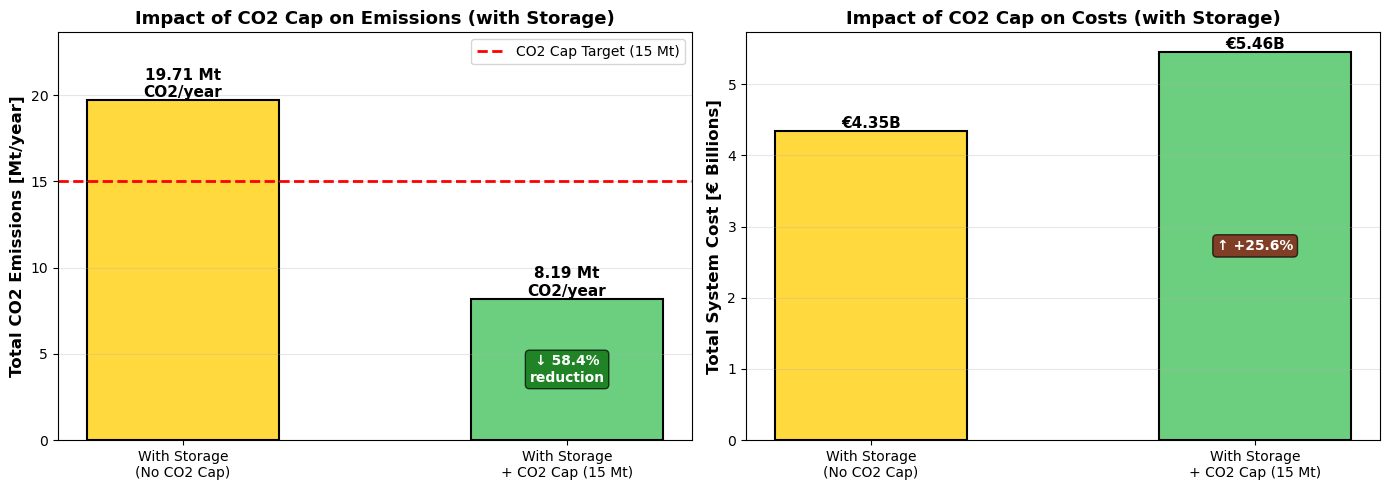


KEY FINDINGS: CO2 CAP EFFECT ON STORAGE-BASED SYSTEM

Cost Impact (vs Storage-only):
  Additional Cost: €+1.11B (+25.6%)

Emissions Impact:
  Storage-only emissions:    19.71 Mt CO2/year
  With CO2 cap emissions:    8.19 Mt CO2/year
  CO2 cap target:            15.0 Mt CO2/year
  Reduction from storage:    11.51 Mt CO2/year (58.4%)

Capacity Changes (Storage vs Storage+CO2 Cap):
  Wind      :   40169 MW →   29993 MW (↓   25.3%)
  Solar     :   89319 MW →   87563 MW (↓    2.0%)
  Battery   :       0 MW →       0 MW (—    0.0%)
  Hydrogen  :       0 MW →       0 MW (—    0.0%)

Fossil Fuel Reduction:
  Coal      :       0 MW →       0 MW (—    0.0%)
  CCGT      :   16476 MW →    3791 MW (↓   77.0%)




In [50]:
# === Comparative Analysis: Emissions and Technology Mix ===
print("\n" + "="*70)
print("COMPARATIVE ANALYSIS: THREE OPTIMIZATION SCENARIOS")
print("="*70 + "\n")

print("\n" + "="*70)
print("COMPARATIVE ANALYSIS: EFFECT OF CO2 CAP ON STORAGE SOLUTION")
print("="*70 + "\n")

# Calculate emissions
def calculate_emissions(solution_df_scenario, tech_params, emission_factors_dict):
    """Helper function to calculate total emissions"""
    total_em = 0.0
    for tech in tech_params.keys():
        if tech in solution_df_scenario.columns:
            total_gen = solution_df_scenario[tech].sum()
            em_factor = emission_factors_dict.get(tech, 0.0)
            total_em += total_gen * em_factor
    return total_em

storage_emissions_total = calculate_emissions(result_with_storage.solution, tech_params_opt, emission_factors)
co2_cap_emissions_total = calculate_emissions(result_co2.solution, tech_params_opt, emission_factors)

# Create comparison dataframe - focus on storage solutions
scenario_comparison = [
    {
        'Scenario': 'With Storage (No CO2 Cap)',
        'Total Cost (€M)': f"{result_with_storage.objective_value/1e6:,.1f}",
        'Wind (MW)': f"{result_with_storage.optimal_capacities.get('Wind', 0):.0f}",
        'Solar (MW)': f"{result_with_storage.optimal_capacities.get('Solar', 0):.0f}",
        'Coal (MW)': f"{result_with_storage.optimal_capacities.get('Coal', 0):.0f}",
        'CCGT (MW)': f"{result_with_storage.optimal_capacities.get('CCGT', 0):.0f}",
        'Battery (MW)': f"{result_with_storage.optimal_capacities.get('battery_power', 0):.0f}",
        'Hydrogen (MW)': f"{result_with_storage.optimal_capacities.get('hydrogen_power', 0):.0f}",
        'Emissions (Mt CO2)': f"{storage_emissions_total/1e9:.2f}",
    },
    {
        'Scenario': f'With Storage + CO2 Cap ({emission_cap_mtonnes} Mt)',
        'Total Cost (€M)': f"{result_co2.objective_value/1e6:,.1f}",
        'Wind (MW)': f"{result_co2.optimal_capacities.get('Wind', 0):.0f}",
        'Solar (MW)': f"{result_co2.optimal_capacities.get('Solar', 0):.0f}",
        'Coal (MW)': f"{result_co2.optimal_capacities.get('Coal', 0):.0f}",
        'CCGT (MW)': f"{result_co2.optimal_capacities.get('CCGT', 0):.0f}",
        'Battery (MW)': f"{result_co2.optimal_capacities.get('battery_power', 0):.0f}",
        'Hydrogen (MW)': f"{result_co2.optimal_capacities.get('hydrogen_power', 0):.0f}",
        'Emissions (Mt CO2)': f"{co2_cap_emissions_total/1e9:.2f}",
    },
]

comparison_df = pd.DataFrame(scenario_comparison)
print("\nSCENARIO COMPARISON TABLE:\n")
display(comparison_df)

# Visualization: Emissions and Cost comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Emissions comparison
scenarios = ['With Storage\n(No CO2 Cap)', f'With Storage\n+ CO2 Cap ({emission_cap_mtonnes} Mt)']
emissions = [storage_emissions_total/1e9, co2_cap_emissions_total/1e9]
colors_scenario = ['#ffd93d', '#6bcf7f']

bars_em = ax1.bar(scenarios, emissions, color=colors_scenario, edgecolor='black', linewidth=1.5, width=0.5)
ax1.axhline(y=emission_cap_mtonnes, color='red', linestyle='--', linewidth=2, label=f'CO2 Cap Target ({emission_cap_mtonnes} Mt)')
ax1.set_ylabel('Total CO2 Emissions [Mt/year]', fontsize=12, fontweight='bold')
ax1.set_title('Impact of CO2 Cap on Emissions (with Storage)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim([0, max(emissions) * 1.2])

# Add value labels and reduction percentage
for i, (bar, em) in enumerate(zip(bars_em, emissions)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{em:.2f} Mt\nCO2/year', ha='center', va='bottom', fontsize=11, fontweight='bold')
    if i == 1:
        reduction_pct = ((emissions[0] - em) / emissions[0] * 100) if emissions[0] > 0 else 0
        ax1.text(bar.get_x() + bar.get_width()/2., height*0.5,
                f'↓ {reduction_pct:.1f}%\nreduction', ha='center', va='center', 
                fontsize=10, fontweight='bold', color='white', bbox=dict(boxstyle='round', facecolor='darkgreen', alpha=0.7))

# Cost comparison
costs = [result_with_storage.objective_value/1e9, result_co2.objective_value/1e9]
bars_cost = ax2.bar(scenarios, costs, color=colors_scenario, edgecolor='black', linewidth=1.5, width=0.5)
ax2.set_ylabel('Total System Cost [€ Billions]', fontsize=12, fontweight='bold')
ax2.set_title('Impact of CO2 Cap on Costs (with Storage)', fontsize=13, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

# Add value labels and cost increase
for i, (bar, cost) in enumerate(zip(bars_cost, costs)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'€{cost:.2f}B', ha='center', va='bottom', fontsize=11, fontweight='bold')
    if i == 1:
        cost_increase_pct = ((cost - costs[0]) / costs[0] * 100) if costs[0] > 0 else 0
        ax2.text(bar.get_x() + bar.get_width()/2., height*0.5,
                f'↑ {cost_increase_pct:+.1f}%', ha='center', va='center', 
                fontsize=10, fontweight='bold', color='white', bbox=dict(boxstyle='round', facecolor='darkred', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDINGS: CO2 CAP EFFECT ON STORAGE-BASED SYSTEM")
print("="*70)

cost_increase_storage = ((result_co2.objective_value - result_with_storage.objective_value) / result_with_storage.objective_value) * 100
emission_reduction_storage = ((storage_emissions_total - co2_cap_emissions_total) / storage_emissions_total * 100) if storage_emissions_total > 0 else 0

print(f"\nCost Impact (vs Storage-only):")
print(f"  Additional Cost: €{(result_co2.objective_value - result_with_storage.objective_value)/1e9:+.2f}B ({cost_increase_storage:+.1f}%)")

print(f"\nEmissions Impact:")
print(f"  Storage-only emissions:    {storage_emissions_total/1e9:.2f} Mt CO2/year")
print(f"  With CO2 cap emissions:    {co2_cap_emissions_total/1e9:.2f} Mt CO2/year")
print(f"  CO2 cap target:            {emission_cap_mtonnes:.1f} Mt CO2/year")
print(f"  Reduction from storage:    {(storage_emissions_total - co2_cap_emissions_total)/1e9:.2f} Mt CO2/year ({emission_reduction_storage:.1f}%)")

print(f"\nCapacity Changes (Storage vs Storage+CO2 Cap):")
for tech in ['Wind', 'Solar', 'Battery', 'Hydrogen']:
    if tech in ['Battery', 'Hydrogen']:
        storage_cap = result_with_storage.optimal_capacities.get(tech + '_power', 0)
        co2_cap = result_co2.optimal_capacities.get(tech + '_power', 0)
    else:
        storage_cap = result_with_storage.optimal_capacities.get(tech, 0)
        co2_cap = result_co2.optimal_capacities.get(tech, 0)
    
    change = co2_cap - storage_cap
    pct_change = (change / storage_cap * 100) if storage_cap > 0 else (100 if co2_cap > 0 else 0)
    symbol = "↑" if change > 0 else ("↓" if change < 0 else "—")
    print(f"  {tech:10s}: {storage_cap:>7.0f} MW → {co2_cap:>7.0f} MW ({symbol} {abs(pct_change):>6.1f}%)")

print(f"\nFossil Fuel Reduction:")
for tech in ['Coal', 'CCGT']:
    storage_cap = result_with_storage.optimal_capacities.get(tech, 0)
    co2_cap = result_co2.optimal_capacities.get(tech, 0)
    change = co2_cap - storage_cap
    pct_change = (change / storage_cap * 100) if storage_cap > 0 else 0
    symbol = "↑" if change > 0 else ("↓" if change < 0 else "—")
    print(f"  {tech:10s}: {storage_cap:>7.0f} MW → {co2_cap:>7.0f} MW ({symbol} {abs(pct_change):>6.1f}%)")

print(f"\n{'='*70}\n")